<a href="https://colab.research.google.com/github/WiggleCode/AAI-511-Group3-Final-Project/blob/Rajni-Massoun/Final_Team_Project_Group3_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Composer Classification Using CNN and LSTM Networks

## AAI-511: Neural Networks and Deep Learning — Final Team Project

**Team Members:** Ashley Figueroa, Jeffery Smith, and Rajni Massoun  
**Date:** August 10, 2026

---

## Introduction

Music is a widely shared art form with a rich history, and composers often
develop recognizable patterns in rhythm, pitch, harmony, texture, and
structure. Identifying the composer of an unfamiliar score can nevertheless be
difficult, particularly for novice musicians and listeners. This project
investigates whether deep learning can learn composer-specific patterns from
symbolic MIDI representations.

In accordance with the assignment instructions, this project predicts only
four composers:

1. Bach
2. Beethoven
3. Chopin
4. Mozart

Two architectures are compared. A **Convolutional Neural Network (CNN)** treats
a piano roll as a time-by-pitch image and learns local musical motifs. A
**Long Short-Term Memory (LSTM)** network treats the same representation as a
sequence and learns temporal dependencies.

# 1. Project Objectives

The primary objective is to develop and compare CNN and LSTM models that
classify a MIDI score as Bach, Beethoven, Chopin, or Mozart.

The project specifically aims to:

1. Filter the supplied archive to the four required composers;
2. Assess file quality, duplicates, and class balance;
3. Extract interpretable note, chord, pitch, tempo, velocity, and duration
   features;
4. Convert MIDI files into normalized piano-roll segments;
5. Split source compositions before segmentation to prevent data leakage;
6. Apply musically appropriate augmentation only to training data;
7. Build and train comparable CNN and LSTM classifiers;
8. Evaluate both models using accuracy, precision, recall, F1-score, and
   confusion matrices at the segment and composition levels; and
9. Fine-tune the stronger architecture using validation data before one final
   test evaluation.

# 2. Methodology

The workflow follows the assignment requirements:

1. **Data collection:** Use the supplied `midiclassics.zip` archive.
2. **Composer filtering:** Retain only Bach, Beethoven, Chopin, and Mozart.
3. **Data preprocessing:** Extract MIDI files, remove exact duplicates,
   construct balanced classes, normalize velocities, pad short segments, and
   divide compositions into fixed-length piano rolls.
4. **Data augmentation:** Apply small pitch transpositions and time masking
   only during training.
5. **Feature extraction:** Extract notes, chords, tempo, pitch, velocity,
   duration, time-signature changes, and instrumentation.
6. **Model building:** Develop CNN and LSTM multiclass classifiers.
7. **Model training:** Train with early stopping and adaptive learning rates.
8. **Model evaluation:** Report accuracy, macro precision, macro recall,
   macro F1-score, classification reports, and confusion matrices.
9. **Model optimization:** Compare controlled hyperparameter configurations
   using validation macro F1-score and evaluate the selected model once on the
   untouched test set.

The source files are divided before segmentation. This prevents highly similar
excerpts from the same composition from appearing in more than one partition.

# 3. Environment Setup

In [1]:
%pip install -q music21 pretty-midi mido seaborn scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.4 MB/s eta 0:00:00


In [2]:
# Core imports and reproducibility
from pathlib import Path, PurePosixPath
import hashlib
import os
import random
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi
from music21 import chord, converter, note

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input,
    LSTM,
    Masking,
)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("once", category=RuntimeWarning)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 4. Dataset Extraction and Required-Composer Filtering

The archive contains substantially more Bach files than the other required
composers. To prevent the classifier from favoring Bach and to keep the
experiment computationally manageable, a reproducible balanced subset is
created after duplicate removal. The subset size is determined by the smallest
available required class.

In [4]:
ZIP_PATH = Path("midiclassics.zip")
DATA_DIR = Path("midiclassics")
REQUIRED_COMPOSERS = ["bach", "beethoven", "chopin", "mozart"]

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"{ZIP_PATH.resolve()} was not found. Place midiclassics.zip "
        "in the same folder as this notebook."
    )

# Determine whether the archive still needs to be extracted
existing_midi_files = (
    [
        path
        for path in DATA_DIR.rglob("*")
        if path.is_file() and path.suffix.lower() in {".mid", ".midi"}
    ]
    if DATA_DIR.exists()
    else []
)

if not existing_midi_files:
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as archive:
        archive.extractall(DATA_DIR)

    print(f"Dataset extracted to: {DATA_DIR.resolve()}")
else:
    print(f"Using existing dataset directory: {DATA_DIR.resolve()}")

print(
    "MIDI files found after extraction:",
    len(
        [
            path
            for path in DATA_DIR.rglob("*")
            if path.is_file()
            and path.suffix.lower() in {".mid", ".midi"}
        ]
    ),
)

Dataset extracted to: /content/midiclassics
MIDI files found after extraction: 4659


In [5]:
def inventory_required_midi_files(data_dir):
    records = []

    for path in sorted(data_dir.rglob("*")):
        if not path.is_file():
            continue

        if path.suffix.lower() not in {".mid", ".midi"}:
            continue

        relative_path = path.relative_to(data_dir)

        # Search every folder component for a required composer.
        path_parts = [part.strip().lower() for part in relative_path.parts]

        composer_matches = [
            composer
            for composer in REQUIRED_COMPOSERS
            if composer in path_parts
        ]

        # Ignore files that cannot be assigned to exactly one required composer.
        if len(composer_matches) != 1:
            continue

        composer = composer_matches[0]
        file_hash = hashlib.sha256(path.read_bytes()).hexdigest()

        records.append(
            {
                "file_path": str(path),
                "relative_path": str(relative_path),
                "filename": path.name,
                "composer": composer,
                "file_size_kb": path.stat().st_size / 1024,
                "sha256": file_hash,
            }
        )

    return pd.DataFrame(records)


full_inventory = inventory_required_midi_files(DATA_DIR)

if full_inventory.empty:
    raise ValueError(
        "No required-composer MIDI files were found. "
        f"Check the extracted folders inside {DATA_DIR.resolve()}."
    )

discovered_counts = (
    full_inventory["composer"]
    .value_counts()
    .reindex(REQUIRED_COMPOSERS, fill_value=0)
    .rename("files_discovered")
)

display(discovered_counts.to_frame())

missing_composers = discovered_counts[
    discovered_counts == 0
].index.tolist()

if missing_composers:
    raise ValueError(
        f"Missing required composers: {missing_composers}"
    )

,files_discovered
composer,
bach,1024
beethoven,213
chopin,136
mozart,257


### Archive Audit

The supplied archive was inspected before revision and contained:

- Bach: **1,024 MIDI files**
- Beethoven: **213 MIDI files**
- Chopin: **136 MIDI files**
- Mozart: **257 MIDI files**

These counts confirm that all four required composers are present, but the raw
distribution is highly imbalanced. Exact duplicate files are removed before
sampling because duplicated byte-identical compositions could otherwise appear
in different partitions and inflate model performance.

In [6]:
# Remove exact byte-identical duplicates within the required-composer inventory.
unique_inventory = (
    full_inventory
    .sort_values(["composer", "relative_path"])
    .drop_duplicates(subset=["sha256"], keep="first")
    .reset_index(drop=True)
)

duplicates_removed = len(full_inventory) - len(unique_inventory)
unique_counts = (
    unique_inventory["composer"]
    .value_counts()
    .reindex(REQUIRED_COMPOSERS, fill_value=0)
)

files_per_composer = int(unique_counts.min())

balanced_inventory = (
    unique_inventory
    .groupby("composer", group_keys=False)
    .sample(n=files_per_composer, random_state=SEED)
    .sort_values(["composer", "relative_path"])
    .reset_index(drop=True)
)

print(f"Exact duplicate files removed: {duplicates_removed}")
print(f"Balanced files per composer: {files_per_composer}")
print(f"Total balanced source files: {len(balanced_inventory)}")
display(
    balanced_inventory["composer"]
    .value_counts()
    .reindex(REQUIRED_COMPOSERS)
    .rename("selected_files")
    .to_frame()
)

Exact duplicate files removed: 20
Balanced files per composer: 132
Total balanced source files: 528


,selected_files
composer,
bach,132
beethoven,132
chopin,132
mozart,132


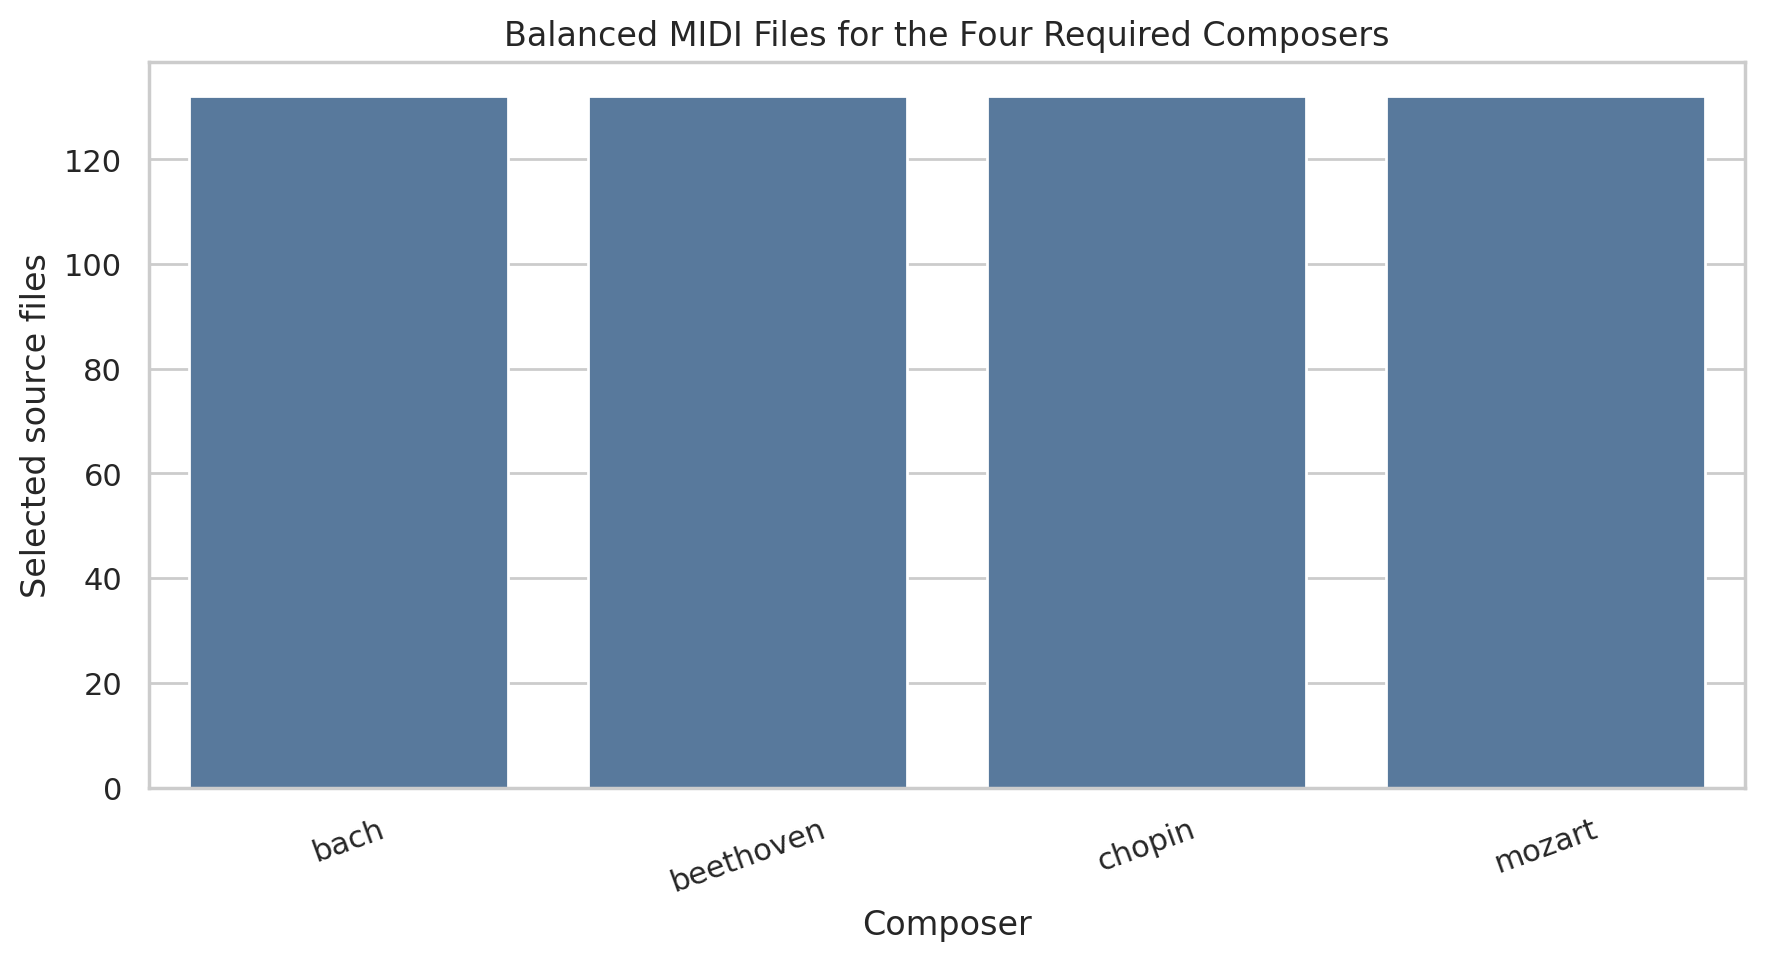

In [7]:
class_counts = (
    balanced_inventory["composer"]
    .value_counts()
    .reindex(REQUIRED_COMPOSERS)
    .rename_axis("composer")
    .reset_index(name="files")
)

plt.figure(figsize=(9, 5))
sns.barplot(data=class_counts, x="composer", y="files", color="#4C78A8")
plt.title("Balanced MIDI Files for the Four Required Composers")
plt.xlabel("Composer")
plt.ylabel("Selected source files")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Dataset Selection Results

Archive validation identified **20 exact duplicate MIDI files** among the four
required classes. After duplicate removal, the unique file counts were 1,014
for Bach, 209 for Beethoven, 132 for Chopin, and 255 for Mozart. No
byte-identical files carried conflicting composer labels.

Because Chopin was the smallest unique class, a reproducible balanced subset of
**132 files per composer** was selected, producing **528 source compositions**
across Bach, Beethoven, Chopin, and Mozart. Balancing at the source-file level
prevents the larger Bach class from dominating model training.

# 5. Data Quality and Musicological Feature Extraction

The original team work used composer-specific heatmaps to investigate note,
pitch, velocity, and duration patterns. That work established the foundation
for the revised EDA. The final analysis uses one consolidated workflow so the
four required composers can be compared directly.

This revision also adds explicit **chord extraction**, as required by the
assignment. `pretty_midi` provides efficient note and tempo features, while
`music21` identifies notes and chord objects from each symbolic score.

In [8]:
from collections import defaultdict
from tqdm.auto import tqdm


def extract_score_features(file_path, composer):
    row = {
        "file_path": str(file_path),
        "filename": Path(file_path).name,
        "composer": composer,
        "parse_error": None,
    }

    try:
        midi = pretty_midi.PrettyMIDI(str(file_path))

        # Collect all non-drum notes
        midi_notes = [
            midi_note
            for instrument in midi.instruments
            if not instrument.is_drum
            for midi_note in instrument.notes
        ]

        if not midi_notes:
            raise ValueError("No non-drum notes found")

        pitches = np.array(
            [midi_note.pitch for midi_note in midi_notes],
            dtype=float,
        )

        velocities = np.array(
            [midi_note.velocity for midi_note in midi_notes],
            dtype=float,
        )

        durations = np.array(
            [
                max(midi_note.end - midi_note.start, 0.0)
                for midi_note in midi_notes
            ],
            dtype=float,
        )

        # ---------------------------------------------------------
        # Approximate chord extraction
        # ---------------------------------------------------------
        # Notes beginning within the same 0.05-second interval are
        # grouped as one simultaneous musical event.
        onset_groups = defaultdict(set)

        for midi_note in midi_notes:
            onset_key = round(midi_note.start / 0.05) * 0.05
            onset_groups[onset_key].add(midi_note.pitch)

        chord_sizes = [
            len(pitches_at_onset)
            for pitches_at_onset in onset_groups.values()
            if len(pitches_at_onset) >= 2
        ]

        total_chords = len(chord_sizes)
        total_onset_events = len(onset_groups)

        # Tempo extraction
        _, tempi = midi.get_tempo_changes()

        try:
            estimated_tempo = midi.estimate_tempo()
        except ValueError:
            estimated_tempo = np.nan

        row.update(
            {
                "total_midi_notes": len(midi_notes),
                "total_onset_events": total_onset_events,
                "total_chords": total_chords,
                "avg_chord_size": (
                    float(np.mean(chord_sizes))
                    if chord_sizes
                    else 0.0
                ),
                "max_chord_size": (
                    int(max(chord_sizes))
                    if chord_sizes
                    else 0
                ),
                "chord_to_event_ratio": (
                    total_chords / total_onset_events
                    if total_onset_events > 0
                    else 0.0
                ),
                "duration_seconds": midi.get_end_time(),
                "avg_pitch": pitches.mean(),
                "pitch_std": pitches.std(),
                "min_pitch": pitches.min(),
                "max_pitch": pitches.max(),
                "pitch_range": pitches.max() - pitches.min(),
                "avg_velocity": velocities.mean(),
                "velocity_std": velocities.std(),
                "avg_note_duration": durations.mean(),
                "estimated_tempo": estimated_tempo,
                "tempo_changes": len(tempi),
                "time_signature_changes": len(
                    midi.time_signature_changes
                ),
                "instrument_count": len(midi.instruments),
            }
        )

    except Exception as exc:
        row["parse_error"] = (
            f"{type(exc).__name__}: {exc}"
        )

    return row


feature_rows = []

for row in tqdm(
    balanced_inventory.itertuples(index=False),
    total=len(balanced_inventory),
    desc="Extracting MIDI features",
):
    feature_rows.append(
        extract_score_features(
            file_path=row.file_path,
            composer=row.composer,
        )
    )

score_features = pd.DataFrame(feature_rows)

quality_summary = pd.DataFrame(
    {
        "selected_files": [len(score_features)],
        "successfully_parsed": [
            score_features["parse_error"].isna().sum()
        ],
        "parse_failures": [
            score_features["parse_error"].notna().sum()
        ],
        "duplicate_paths": [
            score_features["file_path"].duplicated().sum()
        ],
    }
)

display(quality_summary)

if score_features["parse_error"].notna().any():
    display(
        score_features.loc[
            score_features["parse_error"].notna(),
            ["filename", "composer", "parse_error"],
        ]
    )

Extracting MIDI features:   0%|          | 0/528 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


,selected_files,successfully_parsed,parse_failures,duplicate_paths
0,528,528,0,0


### Data Quality Interpretation

> Of the **528** selected MIDI files, **528** were parsed
> successfully and **0** failed. Parse failures were excluded before
> splitting. Tempo-related values should be interpreted cautiously if
> `pretty_midi` reports nonstandard tempo or time-signature event placement.
> Chord extraction adds harmonic information that was not represented
> explicitly in the preliminary analysis.

# 6. Exploratory Data Analysis

The original EDA created one correlation heatmap for each composer. Those
visualizations were valuable during the preliminary investigation because they
revealed within-composer relationships among note count, pitch, velocity, and
duration.

For the final project, the individual heatmaps were condensed—not
disregarded—for three reasons:

1. **Direct comparison:** Composer-level summary tables and comparative
   boxplots show Bach, Beethoven, Chopin, and Mozart in the same view.
2. **Reduced repetition:** One consolidated correlation matrix communicates
   the primary relationships without repeating nearly identical code and chart
   formatting.
3. **Alignment with classification:** The project predicts among composers, so
   differences across composers are more relevant than separate
   within-composer correlation matrices.

The updated EDA preserves the original pitch, velocity, duration, note-count,
tempo, and instrumentation features while adding chord-related variables.
Chords are approximated by grouping notes beginning within the same
0.05-second interval. These variables measure harmonic density but should not
be interpreted as formal chord labels or complete harmonic analysis.

In [9]:
# Keep only files that were parsed successfully
clean_features = score_features.loc[
    score_features["parse_error"].isna()
].copy()

print(
    f"Successfully parsed files available for EDA: "
    f"{len(clean_features):,}"
)

# Features created by the optimized pretty_midi extraction function
requested_numeric_features = [
    "total_midi_notes",
    "total_onset_events",
    "total_chords",
    "avg_chord_size",
    "max_chord_size",
    "chord_to_event_ratio",
    "duration_seconds",
    "avg_pitch",
    "pitch_std",
    "min_pitch",
    "max_pitch",
    "pitch_range",
    "avg_velocity",
    "velocity_std",
    "avg_note_duration",
    "estimated_tempo",
    "tempo_changes",
    "time_signature_changes",
    "instrument_count",
]

# Use only columns that are actually available
numeric_features = [
    feature
    for feature in requested_numeric_features
    if feature in clean_features.columns
]

missing_features = [
    feature
    for feature in requested_numeric_features
    if feature not in clean_features.columns
]

print(f"Numerical features used: {len(numeric_features)}")

if missing_features:
    print(
        "Features not available and excluded:",
        missing_features,
    )

# Overall descriptive statistics
overall_summary = (
    clean_features[numeric_features]
    .describe()
    .T
    .round(2)
)

display(overall_summary)

# Composer-level comparison
composer_summary = (
    clean_features
    .groupby("composer")[numeric_features]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(composer_summary)

Successfully parsed files available for EDA: 528
Numerical features used: 19


,count,mean,std,min,25%,50%,75%,max
total_midi_notes,528.0,4413.82,5922.28,90.00,805.75,2095.00,5815.25,46897.00
total_onset_events,528.0,1705.86,1844.61,40.00,395.00,984.00,2515.75,10592.00
total_chords,528.0,907.95,1069.14,1.00,203.50,494.50,1280.75,7535.00
avg_chord_size,528.0,3.09,0.73,2.00,2.50,3.01,3.53,5.86
max_chord_size,528.0,6.82,3.05,2.00,4.00,6.00,8.00,17.00
chord_to_event_ratio,528.0,0.57,0.19,0.00,0.43,0.56,0.71,1.00
duration_seconds,528.0,329.54,366.70,17.50,91.72,222.98,441.95,5032.31
avg_pitch,528.0,63.40,3.17,50.73,61.61,63.36,65.39,74.01
pitch_std,528.0,11.16,2.09,5.96,9.69,11.16,12.66,17.61
min_pitch,528.0,32.33,6.32,9.00,28.00,31.00,37.00,60.00


total_midi_notes                  total_onset_events          \
                      mean  median      std               mean  median   
composer                                                                 
bach               1676.87   732.5  2798.65             680.19   388.0   
beethoven          7787.23  4470.0  9028.71            2717.52  2080.0   
chopin             2372.86  1604.5  2699.96            1182.58   842.5   
mozart             5818.30  5073.5  4388.32            2243.16  1828.0   

                   total_chords                  avg_chord_size               \
               std         mean  median      std           mean median   std   
composer                                                                       
bach       1062.08       355.17   208.0   558.35           2.96   3.00  0.67   
beethoven  2260.09      1539.69  1118.5  1521.52           3.27   3.06  0.79   
chopin     1276.91       574.86   374.5   602.11           2.97   2.90  0.68   
mozart     1778.67      1162.08  1023.0   849.82           3.17   3.20  0.76   

          max_chord_size              chord_to_event_ratio               \
                    mean median   std                 mean median   std   
composer                                                                  
bach                4.64    4.0  1.70                 0.61   0.64  0.17   
beethoven           8.42    8.0  3.45                 0.55   0.53  0.18   
chopin              6.25    6.0  1.70                 0.55   0.50  0.23   
mozart              7.95    8.0  3.27                 0.56   0.54  0.16   

          duration_seconds                 avg_pitch              pitch_std  \
                      mean  median     std      mean median   std      mean   
composer                                                                      
bach                148.87   76.80  191.98     62.30  62.26  2.78      9.33   
beethoven           523.21  390.99  538.97     63.64  63.65  2.46     12.26   
chopin              221.29  157.51  186.03     62.82  62.92  4.09     11.83   
mozart              424.79  391.27  295.60     64.84  64.98  2.50     11.25   

                       min_pitch              max_pitch               \
          median   std      mean median   std      mean median   std   
composer                                                               
bach        9.04  1.54     37.79   38.0  5.43     80.83   82.0  4.73   
beethoven  12.43  1.71     30.05   29.0  5.04     91.45   91.0  5.86   
chopin     11.65  2.36     29.61   29.0  5.05     92.37   97.0  9.21   
mozart     11.29  1.30     31.89   30.5  6.10     88.11   88.5  3.60   

          pitch_range               avg_velocity               velocity_std  \
                 mean median    std         mean median    std         mean   
composer                                                                      
bach            43.05   44.0   8.14        89.56  96.00  15.32         2.18   
beethoven       61.41   61.0   9.54        72.49  68.58  17.94        16.84   
chopin          62.77   66.0  11.85        66.64  61.69  21.45        13.37   
mozart          56.21   58.0   8.30        78.27  77.30  17.39        13.61   

                       avg_note_duration              estimated_tempo          \
          median   std              mean median   std            mean  median   
composer                                                                        
bach        0.00  5.03              0.46   0.49  0.17          185.38  175.83   
beethoven  16.50  6.89              0.34   0.28  0.21          197.29  198.21   
chopin     14.02  5.88              0.36   0.26  0.25          191.42  194.53   
mozart     14.41  7.10              0.34   0.28  0.17          199.64  200.91   

                 tempo_changes                time_signature_changes         \
             std          mean median     std                   mean median   
composer                                                         

,missing_values
total_midi_notes,0
total_onset_events,0
total_chords,0
avg_chord_size,0
max_chord_size,0
chord_to_event_ratio,0
duration_seconds,0
avg_pitch,0
pitch_std,0
min_pitch,0


,composer,parsed_files
0,bach,132
1,beethoven,132
2,chopin,132
3,mozart,132


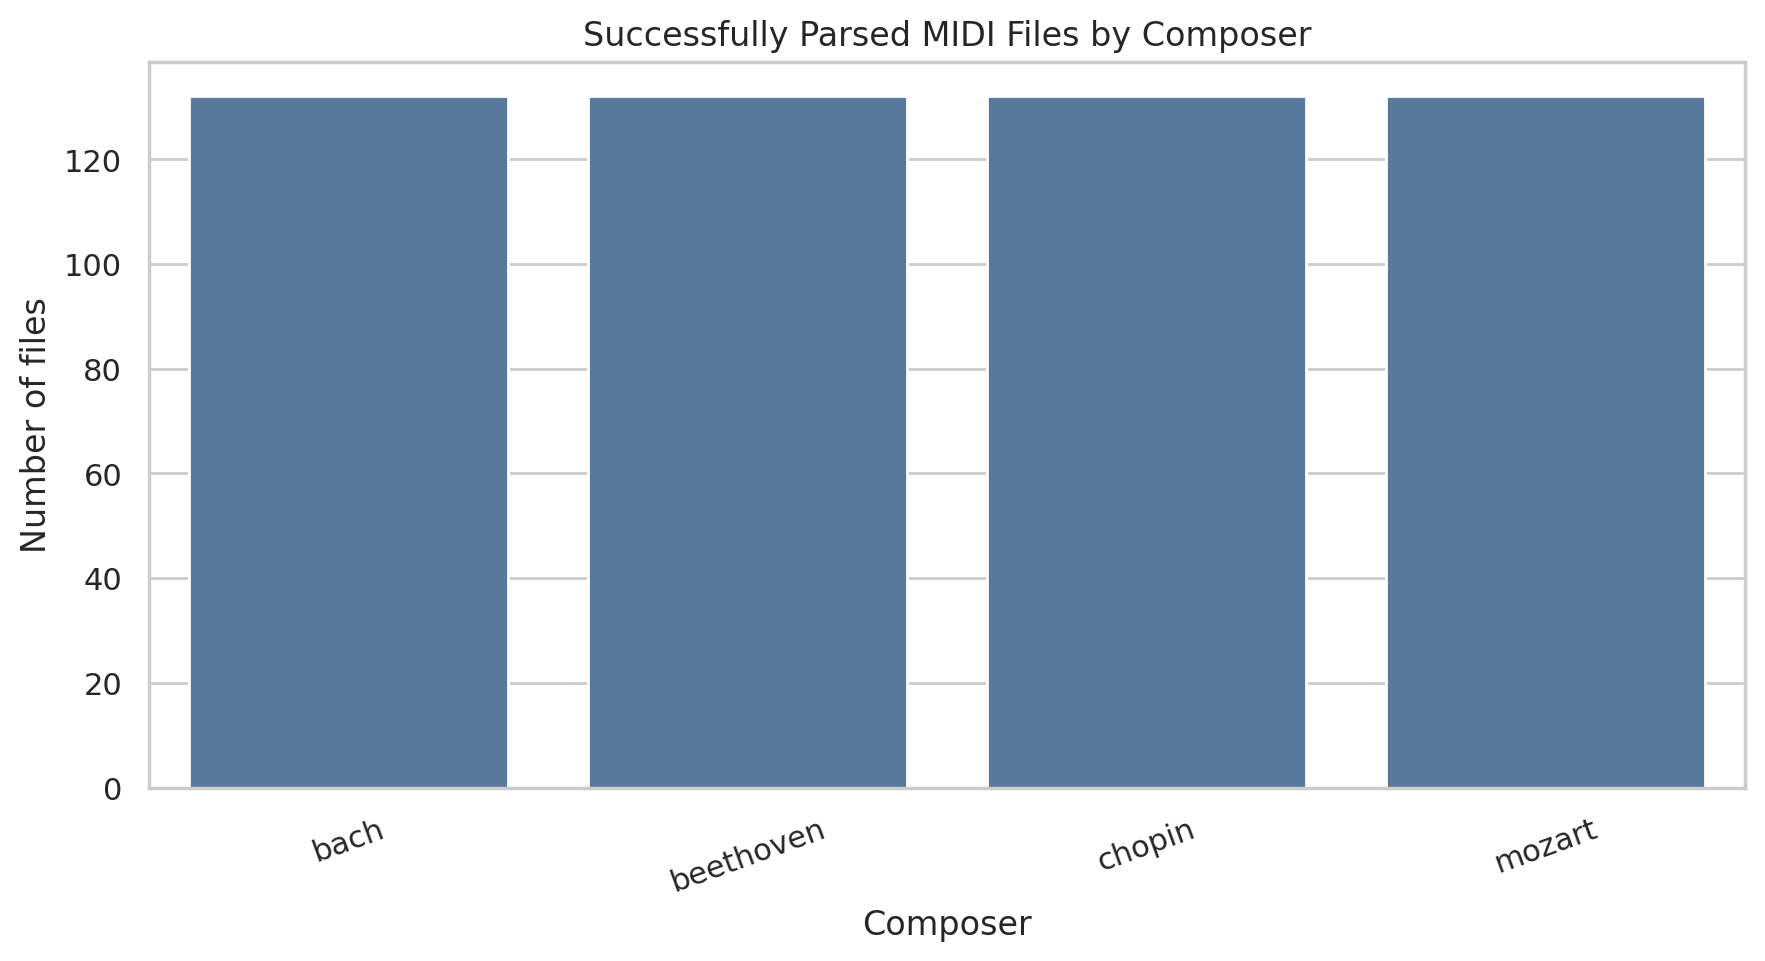

In [10]:
# Data completeness by feature
missing_summary = (
    clean_features[numeric_features]
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

display(missing_summary)

# Number of successfully parsed files by composer
parsed_class_counts = (
    clean_features["composer"]
    .value_counts()
    .reindex(REQUIRED_COMPOSERS, fill_value=0)
    .rename_axis("composer")
    .reset_index(name="parsed_files")
)

display(parsed_class_counts)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=parsed_class_counts,
    x="composer",
    y="parsed_files",
    color="#4C78A8",
)

plt.title("Successfully Parsed MIDI Files by Composer")
plt.xlabel("Composer")
plt.ylabel("Number of files")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

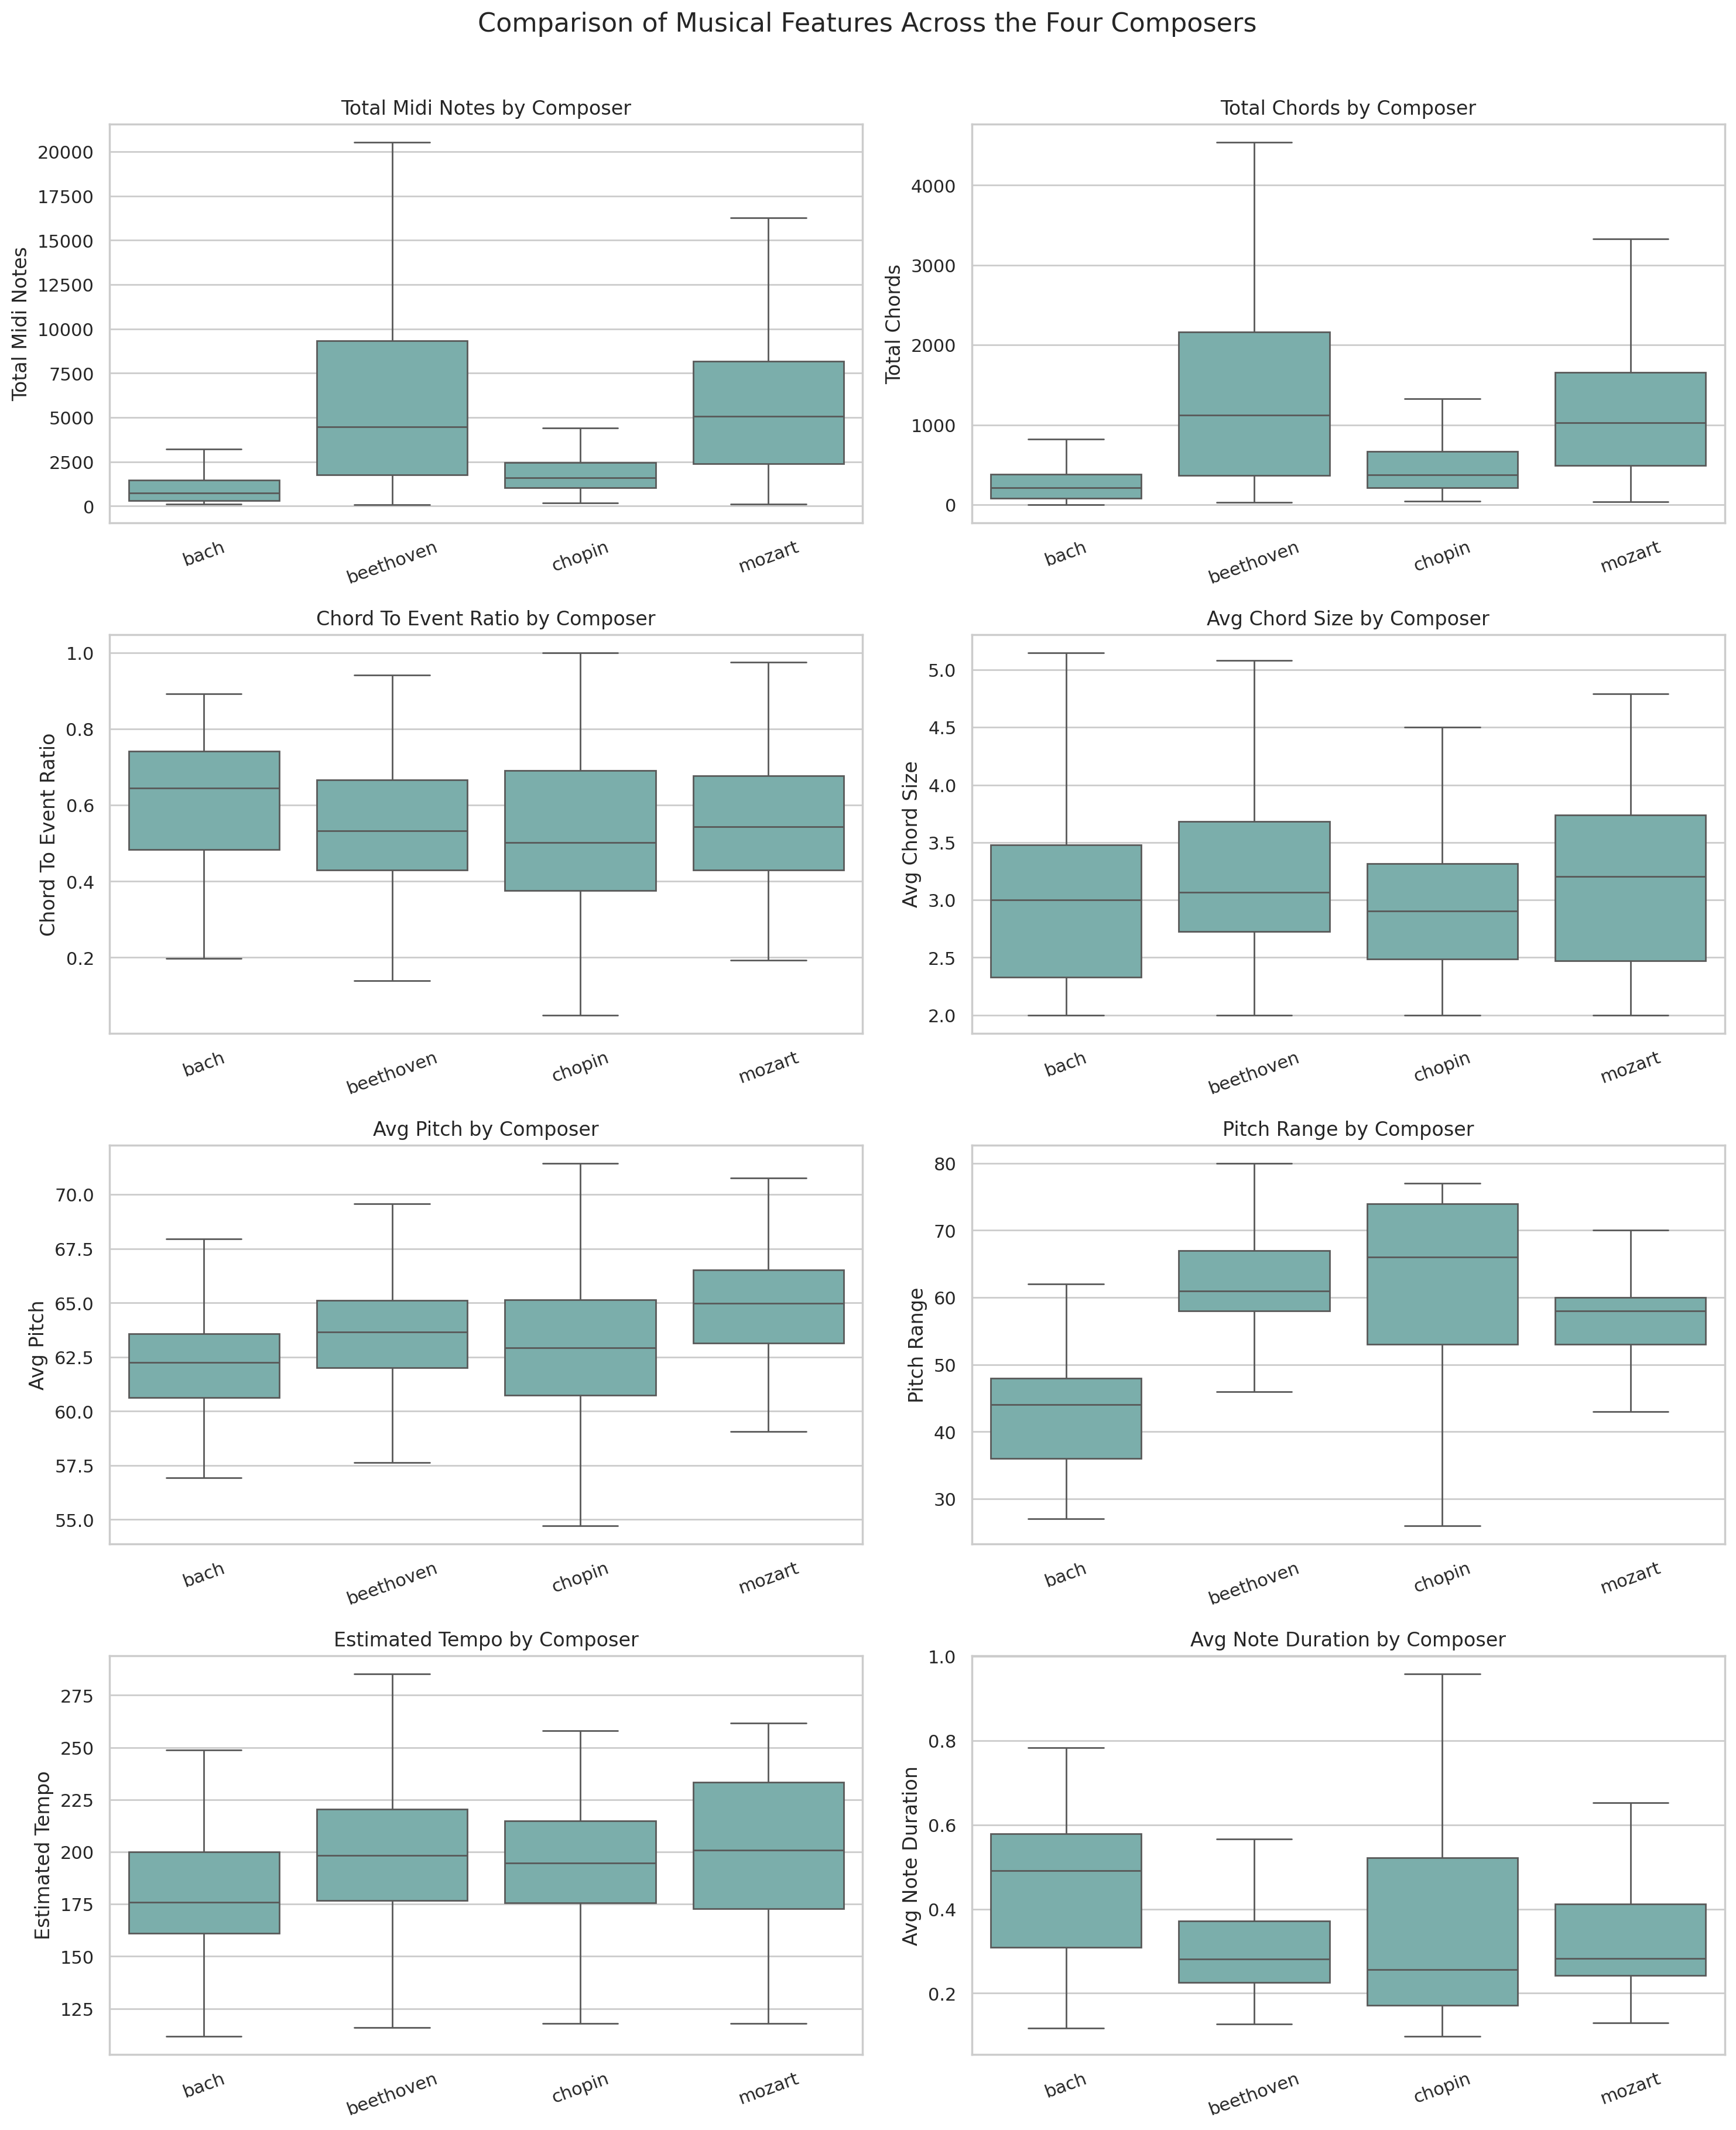

In [11]:
plot_features = [
    "total_midi_notes",
    "total_chords",
    "chord_to_event_ratio",
    "avg_chord_size",
    "avg_pitch",
    "pitch_range",
    "estimated_tempo",
    "avg_note_duration",
]

# Confirm each plotting feature is available
plot_features = [
    feature
    for feature in plot_features
    if feature in clean_features.columns
]

fig, axes = plt.subplots(
    4,
    2,
    figsize=(15, 18),
)

for feature, axis in zip(
    plot_features,
    axes.ravel(),
):
    sns.boxplot(
        data=clean_features,
        x="composer",
        y=feature,
        order=REQUIRED_COMPOSERS,
        ax=axis,
        color="#72B7B2",
        showfliers=False,
    )

    axis.set_title(
        f"{feature.replace('_', ' ').title()} by Composer"
    )
    axis.set_xlabel("")
    axis.set_ylabel(
        feature.replace("_", " ").title()
    )
    axis.tick_params(
        axis="x",
        rotation=20,
    )

# Hide unused axes if fewer than eight features are available
for axis in axes.ravel()[len(plot_features):]:
    axis.set_visible(False)

plt.suptitle(
    "Comparison of Musical Features Across the Four Composers",
    fontsize=16,
    y=1.01,
)

plt.tight_layout()
plt.show()

total_chords                  avg_chord_size               \
                  mean  median      std           mean median   std   
composer                                                              
bach            355.17   208.0   558.35           2.96   3.00  0.67   
beethoven      1539.69  1118.5  1521.52           3.27   3.06  0.79   
chopin          574.86   374.5   602.11           2.97   2.90  0.68   
mozart         1162.08  1023.0   849.82           3.17   3.20  0.76   

          max_chord_size              chord_to_event_ratio               
                    mean median   std                 mean median   std  
composer                                                                 
bach                4.64    4.0  1.70                 0.61   0.64  0.17  
beethoven           8.42    8.0  3.45                 0.55   0.53  0.18  
chopin              6.25    6.0  1.70                 0.55   0.50  0.23  
mozart              7.95    8.0  3.27                 0.56   0.54  0.16

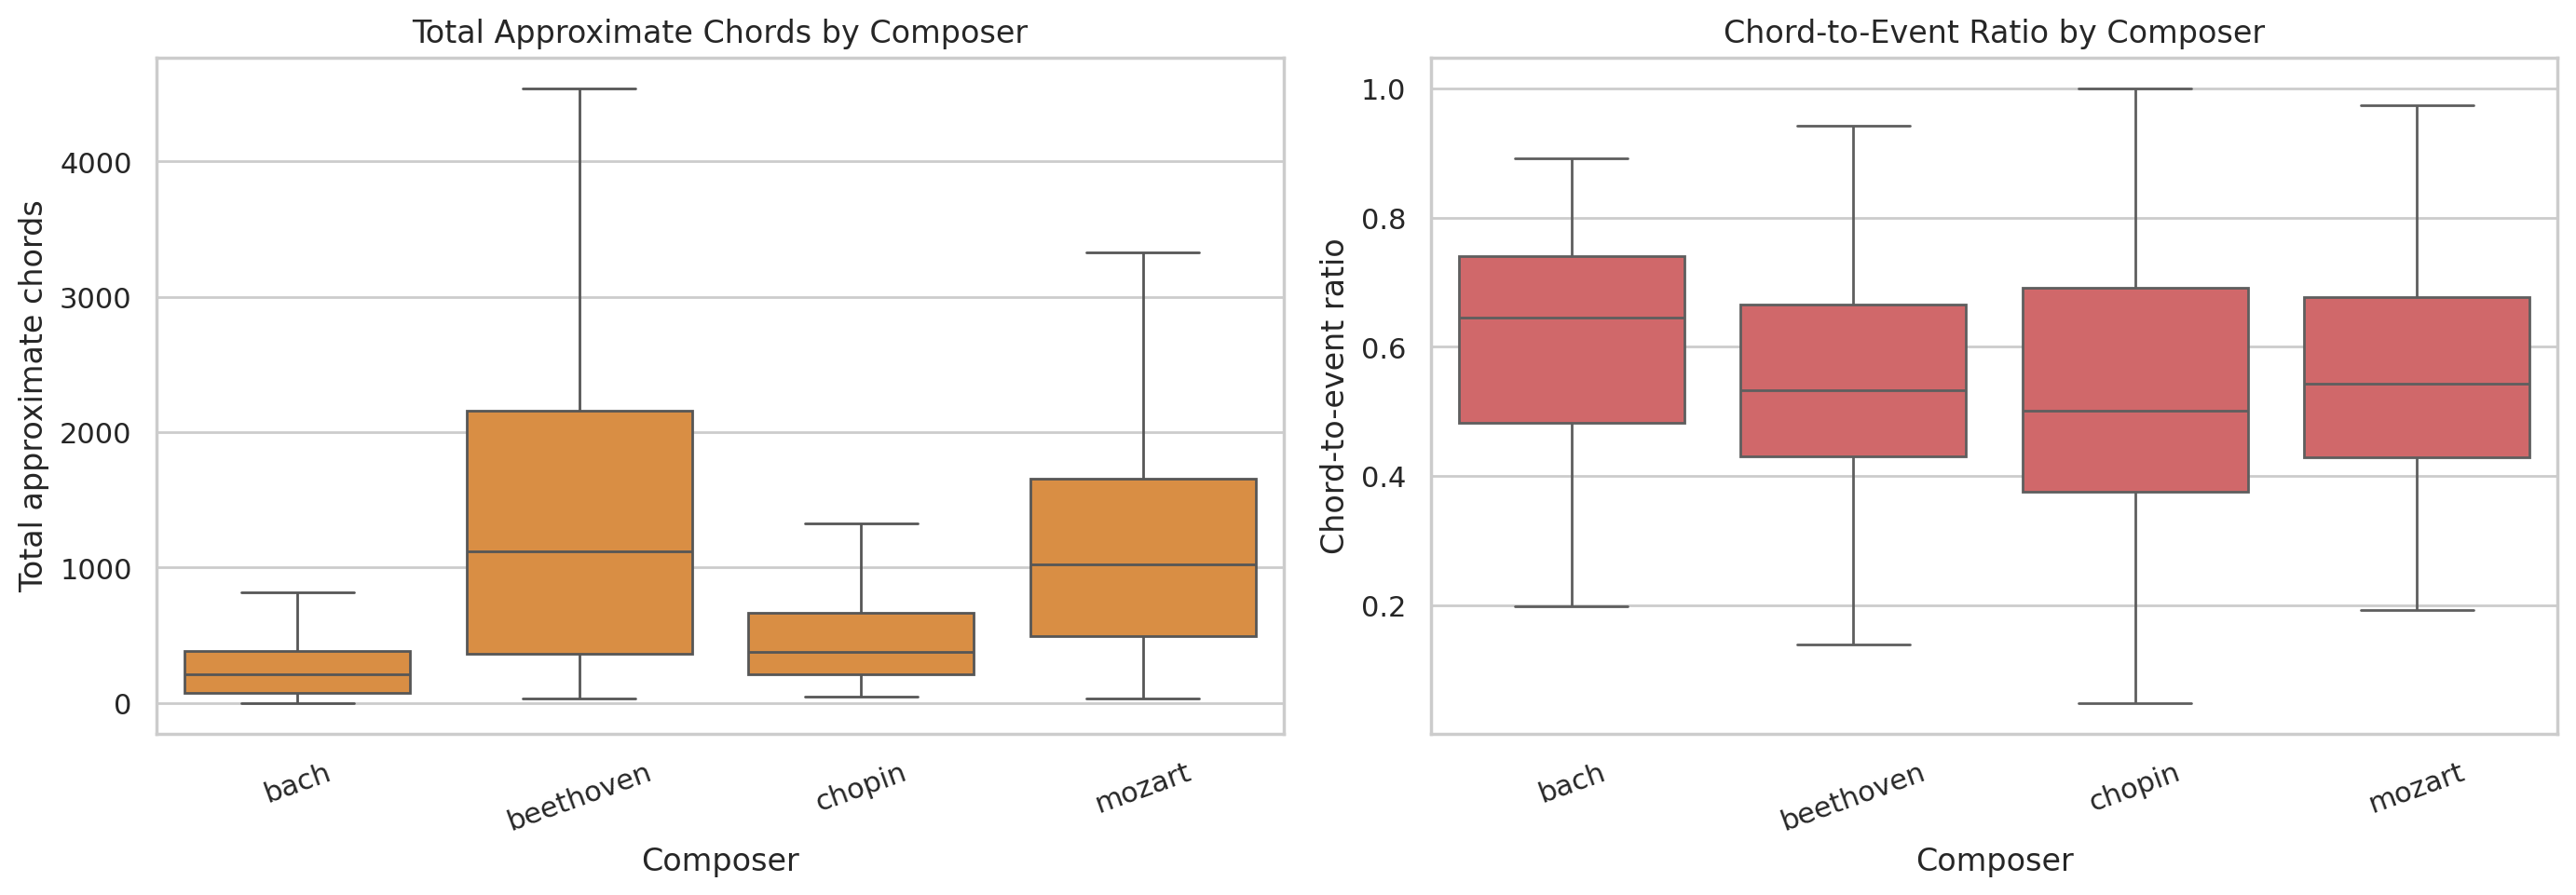

In [12]:
chord_features = [
    "total_chords",
    "avg_chord_size",
    "max_chord_size",
    "chord_to_event_ratio",
]

available_chord_features = [
    feature
    for feature in chord_features
    if feature in clean_features.columns
]

chord_summary = (
    clean_features
    .groupby("composer")[available_chord_features]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(chord_summary)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

sns.boxplot(
    data=clean_features,
    x="composer",
    y="total_chords",
    order=REQUIRED_COMPOSERS,
    color="#F28E2B",
    showfliers=False,
    ax=axes[0],
)

axes[0].set_title("Total Approximate Chords by Composer")
axes[0].set_xlabel("Composer")
axes[0].set_ylabel("Total approximate chords")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=clean_features,
    x="composer",
    y="chord_to_event_ratio",
    order=REQUIRED_COMPOSERS,
    color="#E15759",
    showfliers=False,
    ax=axes[1],
)

axes[1].set_title("Chord-to-Event Ratio by Composer")
axes[1].set_xlabel("Composer")
axes[1].set_ylabel("Chord-to-event ratio")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

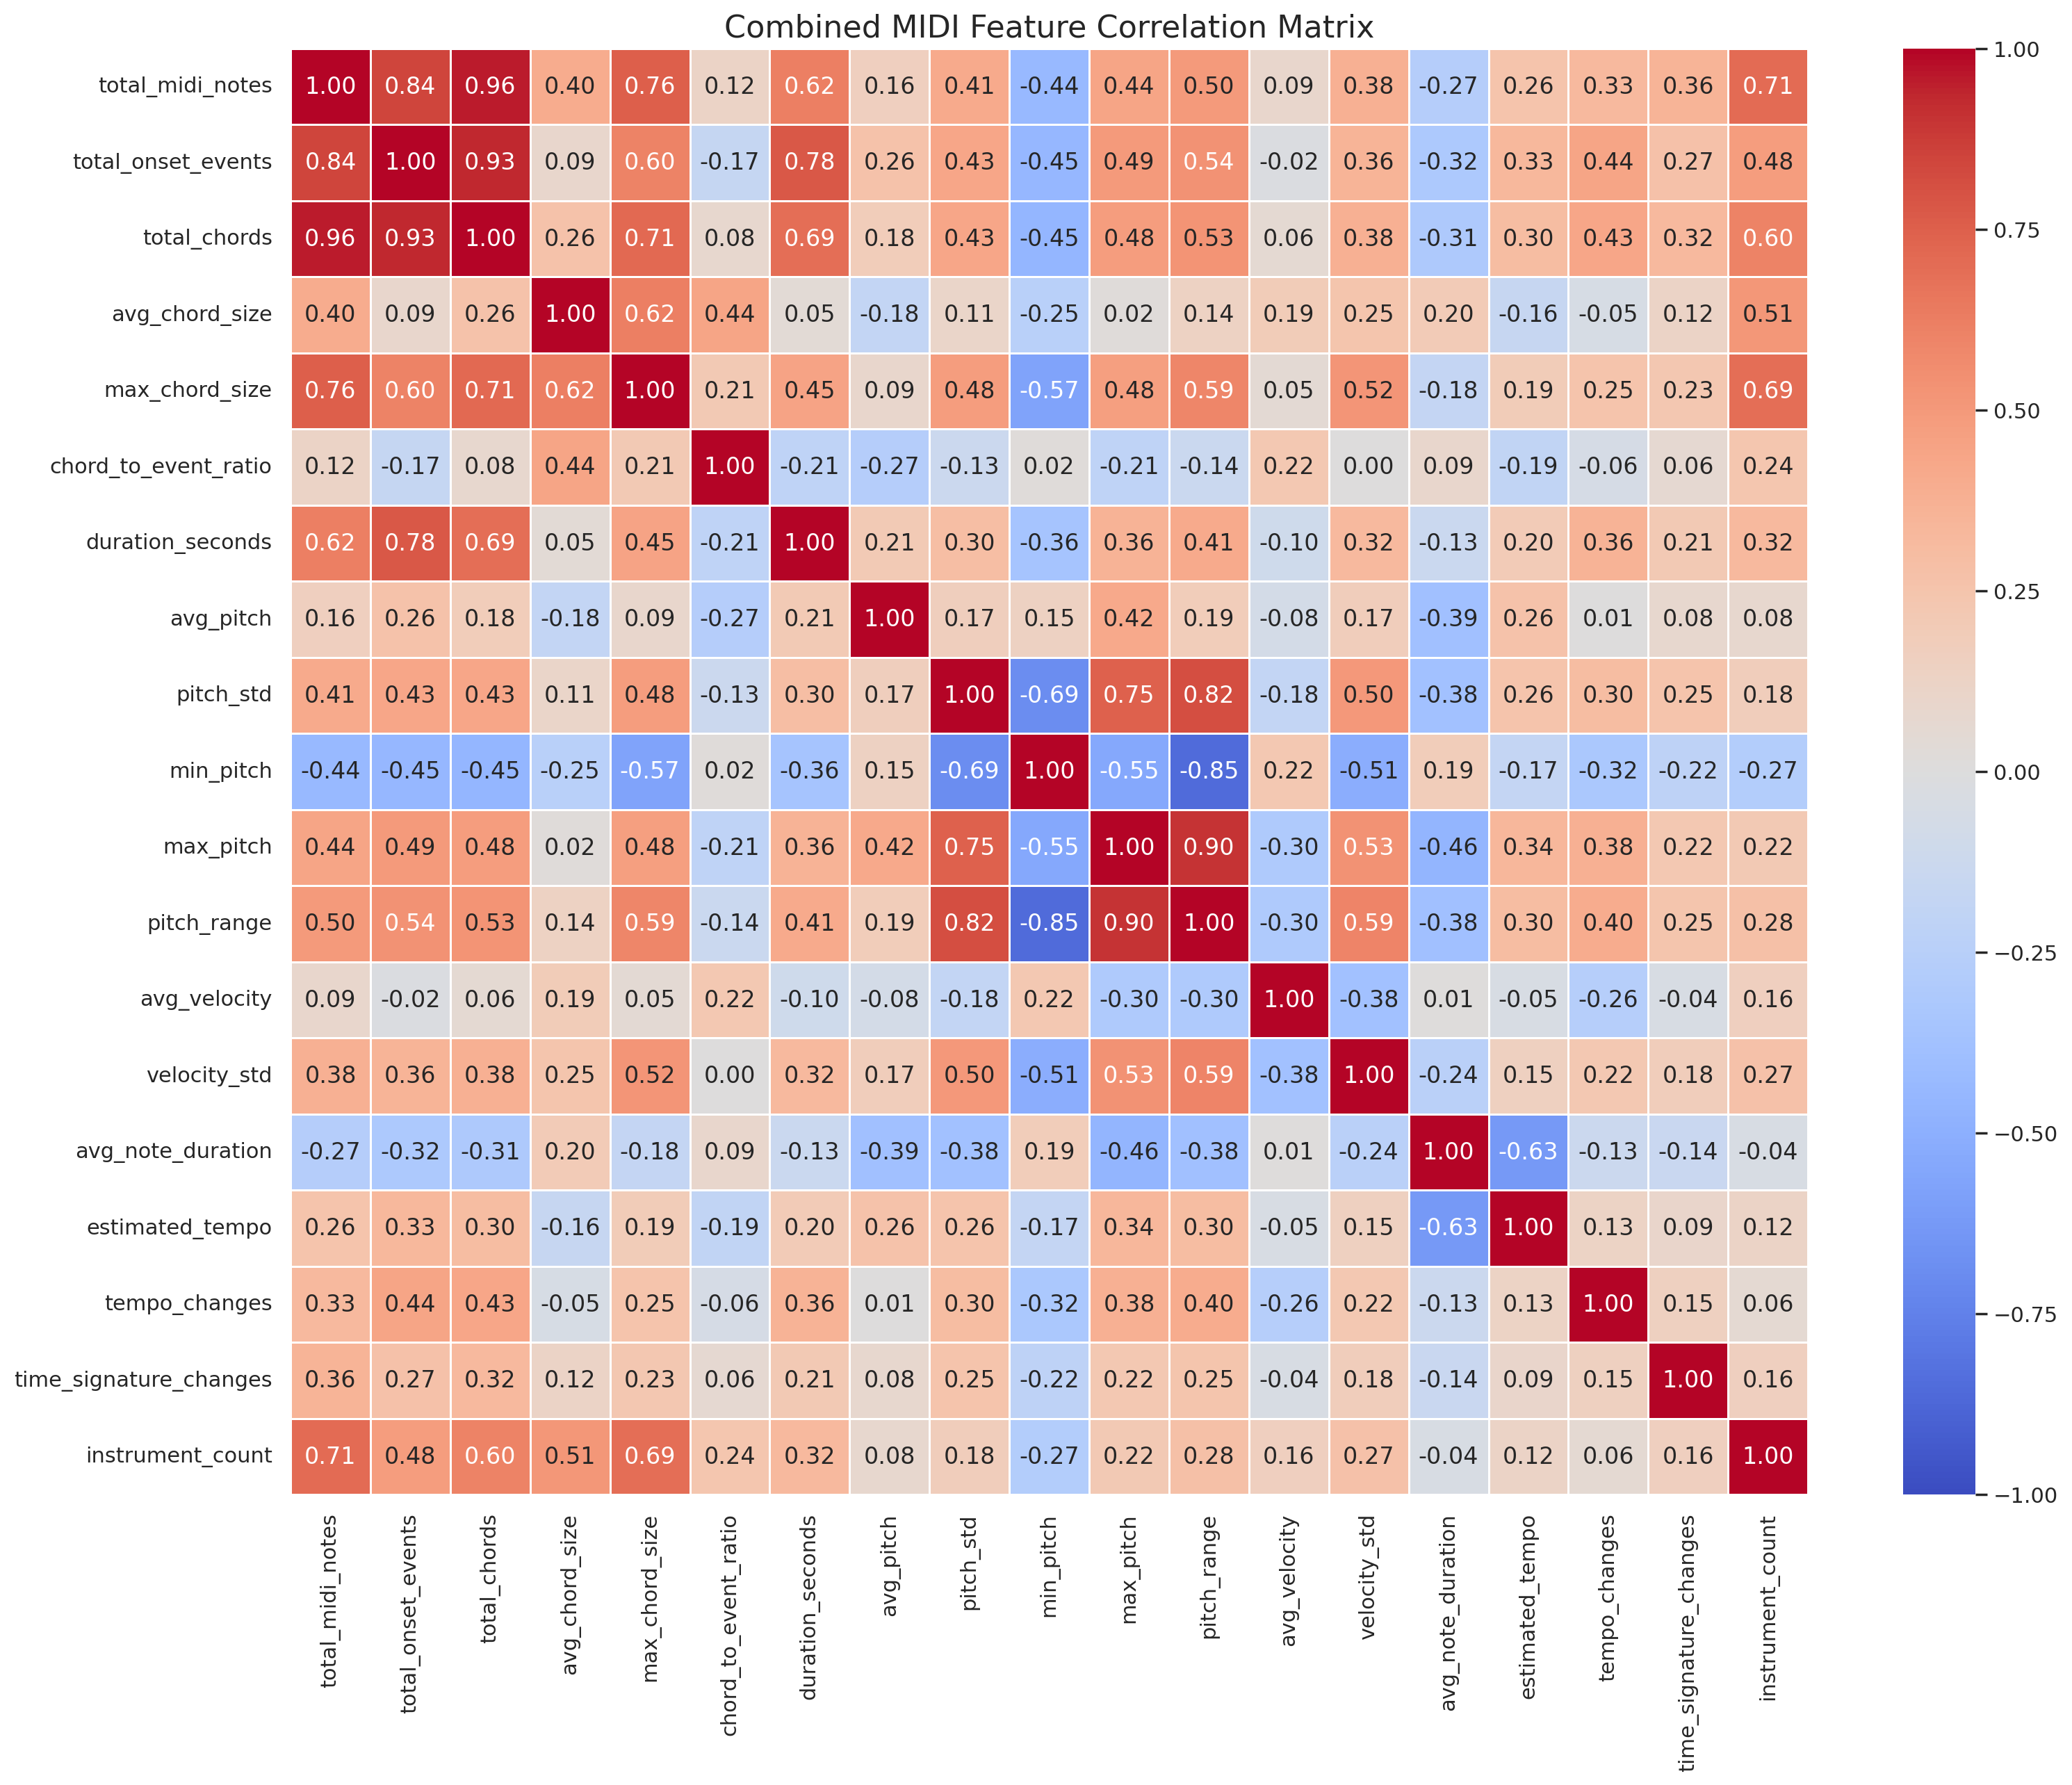

In [13]:
correlation_features = [
    feature
    for feature in numeric_features
    if (
        clean_features[feature].notna().sum() > 1
        and clean_features[feature].nunique(dropna=True) > 1
    )
]

correlation_matrix = (
    clean_features[correlation_features]
    .corr()
)

plt.figure(figsize=(16, 13))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
)

plt.title(
    "Combined MIDI Feature Correlation Matrix",
    fontsize=16,
)

plt.tight_layout()
plt.show()

### Updated EDA Results

The revised EDA compares Bach, Beethoven, Chopin, and Mozart within the same
analytical framework. Overall descriptive statistics summarize the range and
variability of each feature, while composer-level statistics and boxplots
identify differences in note density, approximate chord use, pitch, tempo,
duration, and instrumentation.

The chord variables describe simultaneous pitch activity. `total_chords`
represents the number of onset groups containing at least two distinct pitches,
`avg_chord_size` describes the average number of pitches in those groups, and
`chord_to_event_ratio` estimates the proportion of onset events containing
multiple pitches. These are computational approximations rather than formal
music-theory chord labels.

Constant features are excluded from the combined correlation heatmap because
features without variation cannot produce meaningful correlations. The
remaining correlation coefficients describe associations across the complete
four-composer dataset. They should not be interpreted as causal evidence of
authorship.

No individual feature is expected to distinguish every composer reliably.
Instead, the EDA supports using CNN and LSTM models to learn nonlinear
combinations of pitch, rhythm, duration, harmonic density, and temporal
structure.

# 7. Train, Validation, and Test Split

Only successfully parsed files are retained. The balanced source compositions
are stratified into 70% training, 15% validation, and 15% testing partitions
before segmentation. The test set remains untouched during architecture
comparison and hyperparameter tuning.

In [14]:
usable_files = clean_features[
    ["file_path", "filename", "composer"]
].copy()

train_files, holdout_files = train_test_split(
    usable_files,
    test_size=0.30,
    random_state=SEED,
    stratify=usable_files["composer"],
)

validation_files, test_files = train_test_split(
    holdout_files,
    test_size=0.50,
    random_state=SEED,
    stratify=holdout_files["composer"],
)

split_table = pd.concat(
    [
        train_files.assign(split="train"),
        validation_files.assign(split="validation"),
        test_files.assign(split="test"),
    ],
    ignore_index=True,
)

assert set(train_files["file_path"]).isdisjoint(
    validation_files["file_path"]
)
assert set(train_files["file_path"]).isdisjoint(test_files["file_path"])
assert set(validation_files["file_path"]).isdisjoint(
    test_files["file_path"]
)

split_counts = pd.crosstab(
    split_table["composer"], split_table["split"]
)
display(split_counts)

split,test,train,validation
composer,,,
bach,20,92,20
beethoven,20,93,19
chopin,20,92,20
mozart,20,92,20


# 8. Piano-Roll Preprocessing

Each MIDI file is sampled at 10 frames per second and converted to a
time-by-pitch matrix. A segment contains 100 frames—approximately 10
seconds—and all 128 MIDI pitches. Velocity is normalized from 0–127 to 0–1.
Short final segments are zero-padded, and each file contributes no more than 20
evenly distributed segments so that long compositions do not dominate.

In [15]:
TIME_STEPS = 100
SAMPLE_RATE = 10
N_PITCHES = 128
MAX_SEGMENTS_PER_FILE = 20

label_encoder = LabelEncoder()
label_encoder.fit(REQUIRED_COMPOSERS)
class_names = label_encoder.classes_
number_of_classes = len(class_names)


def midi_to_segments(
    file_path,
    time_steps=TIME_STEPS,
    sample_rate=SAMPLE_RATE,
    max_segments=MAX_SEGMENTS_PER_FILE,
):
    midi = pretty_midi.PrettyMIDI(str(file_path))
    piano_roll = midi.get_piano_roll(fs=sample_rate).T.astype(np.float32)

    if piano_roll.shape[0] == 0:
        return np.empty(
            (0, time_steps, N_PITCHES), dtype=np.float32
        )

    piano_roll /= 127.0
    segments = []

    for start in range(0, piano_roll.shape[0], time_steps):
        segment = piano_roll[start : start + time_steps]
        if segment.shape[0] < time_steps:
            segment = np.pad(
                segment,
                ((0, time_steps - segment.shape[0]), (0, 0)),
                mode="constant",
            )
        segments.append(segment)

    if max_segments and len(segments) > max_segments:
        selected_indices = np.linspace(
            0, len(segments) - 1, max_segments, dtype=int
        )
        segments = [segments[index] for index in selected_indices]

    return np.stack(segments).astype(np.float32)


def build_segment_dataset(file_table):
    features, labels, source_files = [], [], []

    for row in file_table.itertuples(index=False):
        segments = midi_to_segments(row.file_path)
        if len(segments) == 0:
            continue

        label = label_encoder.transform([row.composer])[0]
        features.append(segments)
        labels.extend([label] * len(segments))
        source_files.extend([row.file_path] * len(segments))

    X = np.concatenate(features, axis=0)
    y = np.asarray(labels, dtype=np.int32)
    groups = np.asarray(source_files)
    return X, y, groups


X_train, y_train, train_groups = build_segment_dataset(train_files)
X_validation, y_validation, validation_groups = build_segment_dataset(
    validation_files
)
X_test, y_test, test_groups = build_segment_dataset(test_files)

assert set(train_groups).isdisjoint(validation_groups)
assert set(train_groups).isdisjoint(test_groups)
assert set(validation_groups).isdisjoint(test_groups)

segment_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "segments": [len(y_train), len(y_validation), len(y_test)],
        "source_files": [
            len(np.unique(train_groups)),
            len(np.unique(validation_groups)),
            len(np.unique(test_groups)),
        ],
    }
)
display(segment_summary)
print("Classes:", dict(enumerate(class_names)))

# File classes are balanced, but different composition lengths can still
# produce unequal segment counts. Segment-level class weights compensate.
weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
segment_class_weight = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(y_train), weight_values)
}
print("Training-segment class weights:", segment_class_weight)

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI

,split,segments,source_files
0,train,5605,369
1,validation,1153,79
2,test,1303,80


Classes: {0: np.str_('bach'), 1: np.str_('beethoven'), 2: np.str_('chopin'), 3: np.str_('mozart')}
Training-segment class weights: {0: 1.4688155136268344, 1: 0.8523418491484185, 2: 1.044150521609538, 3: 0.8415915915915916}


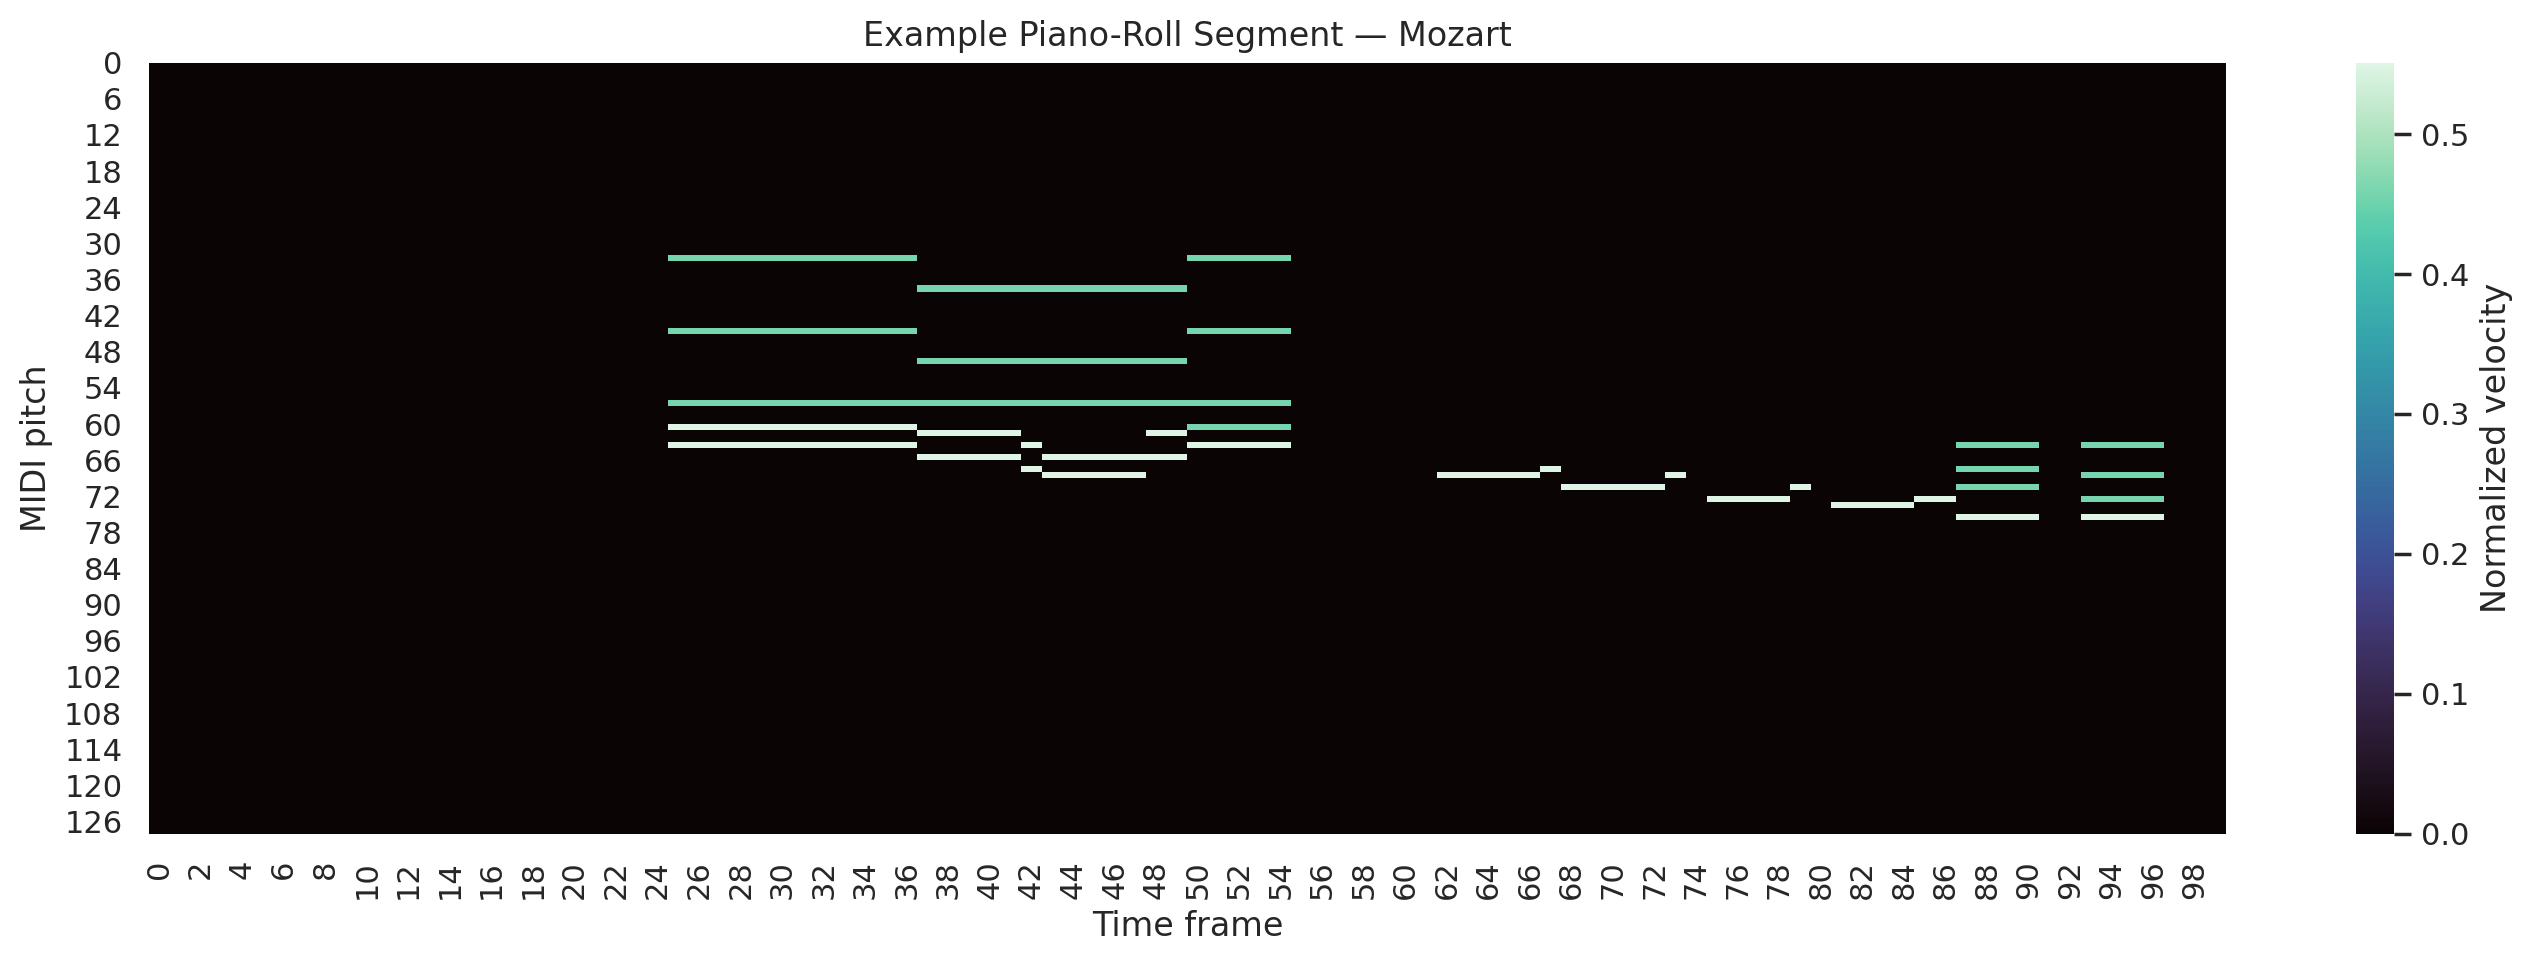

In [16]:
sample_index = 0
plt.figure(figsize=(14, 5))
sns.heatmap(
    X_train[sample_index].T,
    cmap="mako",
    cbar_kws={"label": "Normalized velocity"},
)
plt.title(
    f"Example Piano-Roll Segment — "
    f"{class_names[y_train[sample_index]].title()}"
)
plt.xlabel("Time frame")
plt.ylabel("MIDI pitch")
plt.tight_layout()
plt.show()

# 9. Training-Only Data Augmentation

The assignment requires data augmentation. This pipeline applies two
label-preserving transformations only to training segments:

- **Pitch transposition:** Randomly shift active pitches by up to two
  semitones. Small transpositions preserve the underlying rhythmic and
  structural style while varying absolute key.
- **Time masking:** Set one short time interval to zero. This discourages the
  model from relying on one isolated excerpt.

Validation and test data are never augmented. Pitch shifts are padded with
zeros rather than wrapped, preventing high pitches from reappearing at the
bottom of the MIDI range.

In [17]:
AUTOTUNE = tf.data.AUTOTUNE


def shift_pitch_without_wrap(segment, shift):
    def shift_up():
        return tf.concat(
            [
                tf.zeros_like(segment[:, :shift]),
                segment[:, :-shift],
            ],
            axis=1,
        )

    def shift_down():
        amount = -shift
        return tf.concat(
            [
                segment[:, amount:],
                tf.zeros_like(segment[:, :amount]),
            ],
            axis=1,
        )

    return tf.case(
        [
            (tf.greater(shift, 0), shift_up),
            (tf.less(shift, 0), shift_down),
        ],
        default=lambda: segment,
        exclusive=True,
    )


def augment_piano_roll(segment, label):
    pitch_shift = tf.random.uniform(
        shape=[], minval=-2, maxval=3, dtype=tf.int32
    )
    segment = shift_pitch_without_wrap(segment, pitch_shift)

    mask_length = tf.random.uniform(
        shape=[], minval=5, maxval=16, dtype=tf.int32
    )
    mask_start = tf.random.uniform(
        shape=[],
        minval=0,
        maxval=TIME_STEPS - mask_length + 1,
        dtype=tf.int32,
    )
    time_mask = tf.concat(
        [
            tf.ones((mask_start, 1), dtype=segment.dtype),
            tf.zeros((mask_length, 1), dtype=segment.dtype),
            tf.ones(
                (TIME_STEPS - mask_start - mask_length, 1),
                dtype=segment.dtype,
            ),
        ],
        axis=0,
    )
    segment = segment * time_mask
    return segment, label


def make_dataset(X, y, training=False, cnn=False, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
        dataset = dataset.shuffle(
            min(len(y), 10000),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
        dataset = dataset.map(
            augment_piano_roll,
            num_parallel_calls=AUTOTUNE,
        )

    if cnn:
        dataset = dataset.map(
            lambda segment, label: (
                tf.expand_dims(segment, axis=-1),
                label,
            ),
            num_parallel_calls=AUTOTUNE,
        )

    return dataset.batch(batch_size).prefetch(AUTOTUNE)

# 10. Shared Training Configuration

Sparse categorical cross-entropy is appropriate because the target labels are
integer encoded. Early stopping restores the checkpoint with the lowest
validation loss, and learning-rate reduction makes smaller updates after
validation improvement plateaus.

In [18]:
BATCH_SIZE = 32
EPOCHS = 40


def fresh_callbacks(patience=6):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def compile_model(model, learning_rate=0.001):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_training_history(history, title):
    history_frame = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    history_frame[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")

    history_frame[["accuracy", "val_accuracy"]].plot(ax=axes[1])
    axes[1].set_title(f"{title}: Accuracy")
    axes[1].set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

# 11. Baseline CNN

The CNN learns local time–pitch relationships such as motifs, intervals, chord
shapes, and rhythmic textures. Batch normalization stabilizes training,
dropout reduces overfitting, and global average pooling controls the parameter
count.

Model: "composer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 128, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 49, 63, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 49, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 49, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 31, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,260 (579.14 KB)

 Trainable params: 148,068 (578.39 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.3427 - loss: 1.2811 - val_accuracy: 0.2567 - val_loss: 5.2414 - learning_rate: 0.0010
Epoch 2/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.4384 - loss: 1.1060 - val_accuracy: 0.2567 - val_loss: 9.8568 - learning_rate: 0.0010
Epoch 3/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4753 - loss: 1.0247 - val_accuracy: 0.2576 - val_loss: 8.5809 - learning_rate: 0.0010
Epoch 4/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.4903 - loss: 0.9915 - val_accuracy: 0.4822 - val_loss: 1.0978 - learning_rate: 0.0010
Epoch 5/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5115 - loss: 0.9672 - val_accuracy: 0.5126 - val_loss: 1.0594 - learning_rate: 0.0010
Epoch 6/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5297 - loss: 0.9382 - val_accuracy: 0.4866 - val_loss: 1.0830 - learning_rate: 0.0010
Epoch 7/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5383 - loss: 0

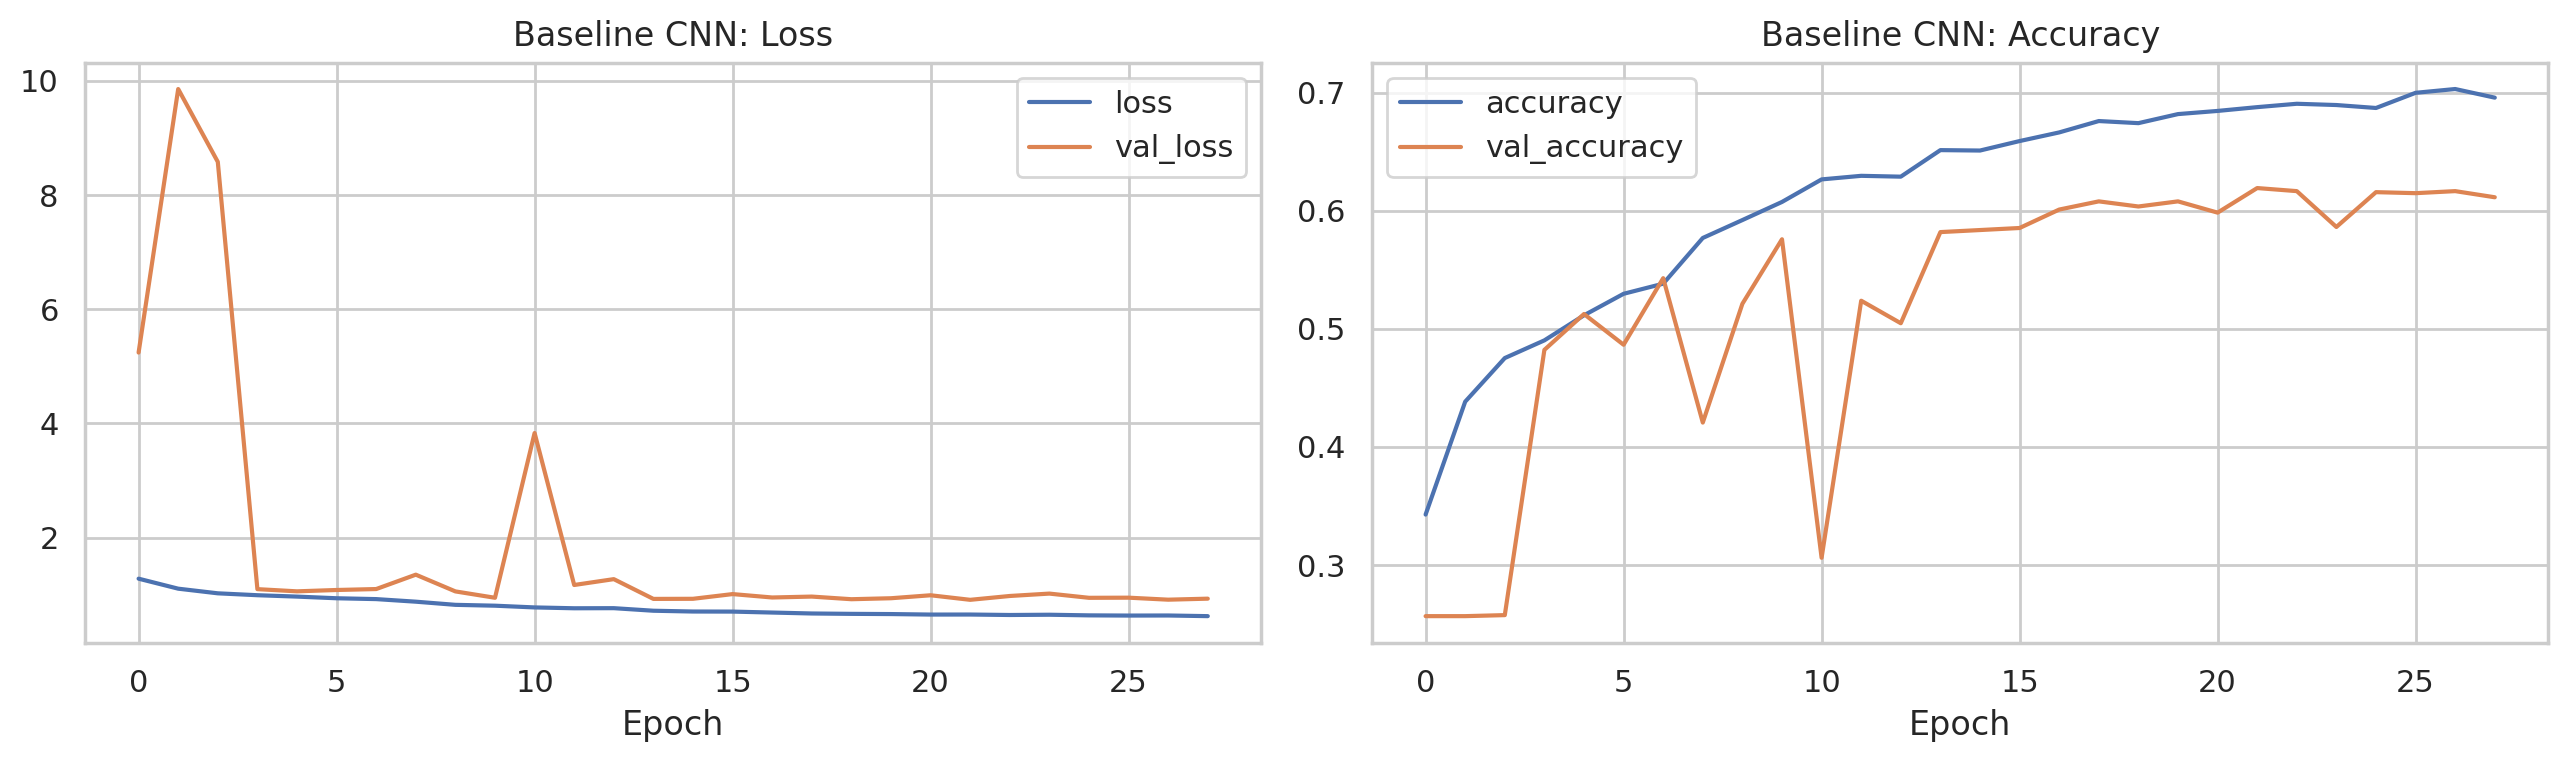

In [19]:
def build_cnn_model(
    filters=(32, 64, 128),
    dropout_rate=0.30,
    learning_rate=0.001,
):
    model = Sequential(
        [
            Input(shape=(TIME_STEPS, N_PITCHES, 1)),
            Conv2D(
                filters[0], (5, 5), activation="relu", padding="same"
            ),
            BatchNormalization(),
            Conv2D(
                filters[0],
                (3, 3),
                activation="relu",
                strides=(2, 2),
            ),
            Dropout(dropout_rate),
            Conv2D(
                filters[1], (3, 3), activation="relu", padding="same"
            ),
            BatchNormalization(),
            Conv2D(
                filters[1],
                (3, 3),
                activation="relu",
                strides=(2, 2),
            ),
            Dropout(dropout_rate),
            Conv2D(
                filters[2], (3, 3), activation="relu", padding="same"
            ),
            GlobalAveragePooling2D(),
            Dense(64, activation="relu"),
            Dropout(min(dropout_rate + 0.10, 0.60)),
            Dense(number_of_classes, activation="softmax"),
        ],
        name="composer_cnn",
    )
    return compile_model(model, learning_rate)


train_cnn_dataset = make_dataset(
    X_train, y_train, training=True, cnn=True, batch_size=BATCH_SIZE
)
validation_cnn_dataset = make_dataset(
    X_validation,
    y_validation,
    training=False,
    cnn=True,
    batch_size=BATCH_SIZE,
)

cnn_model = build_cnn_model()
cnn_model.summary()

cnn_history = cnn_model.fit(
    train_cnn_dataset,
    validation_data=validation_cnn_dataset,
    epochs=EPOCHS,
    class_weight=segment_class_weight,
    callbacks=fresh_callbacks(),
    verbose=1,
)
plot_training_history(cnn_history, "Baseline CNN")

# 12. Baseline LSTM

The LSTM processes each piano roll as a sequence of 100 time frames with 128
pitch values per frame. This tests whether longer temporal dependencies provide
information beyond the CNN's local musical patterns.

Model: "composer_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,668 (725.27 KB)

 Trainable params: 185,540 (724.77 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.2824 - loss: 1.5065 - val_accuracy: 0.2402 - val_loss: 1.3828 - learning_rate: 0.0010
Epoch 2/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3136 - loss: 1.3533 - val_accuracy: 0.2810 - val_loss: 1.3826 - learning_rate: 0.0010
Epoch 3/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3327 - loss: 1.3123 - val_accuracy: 0.3842 - val_loss: 1.2769 - learning_rate: 0.0010
Epoch 4/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.3247 - loss: 1.3347 - val_accuracy: 0.3773 - val_loss: 1.2863 - learning_rate: 0.0010
Epoch 5/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3575 - loss: 1.2913 - val_accuracy: 0.2923 - val_loss: 1.4088 - learning_rate: 0.0010
Epoch 6/40
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3571 - loss: 1.2957
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3556 - loss: 1.

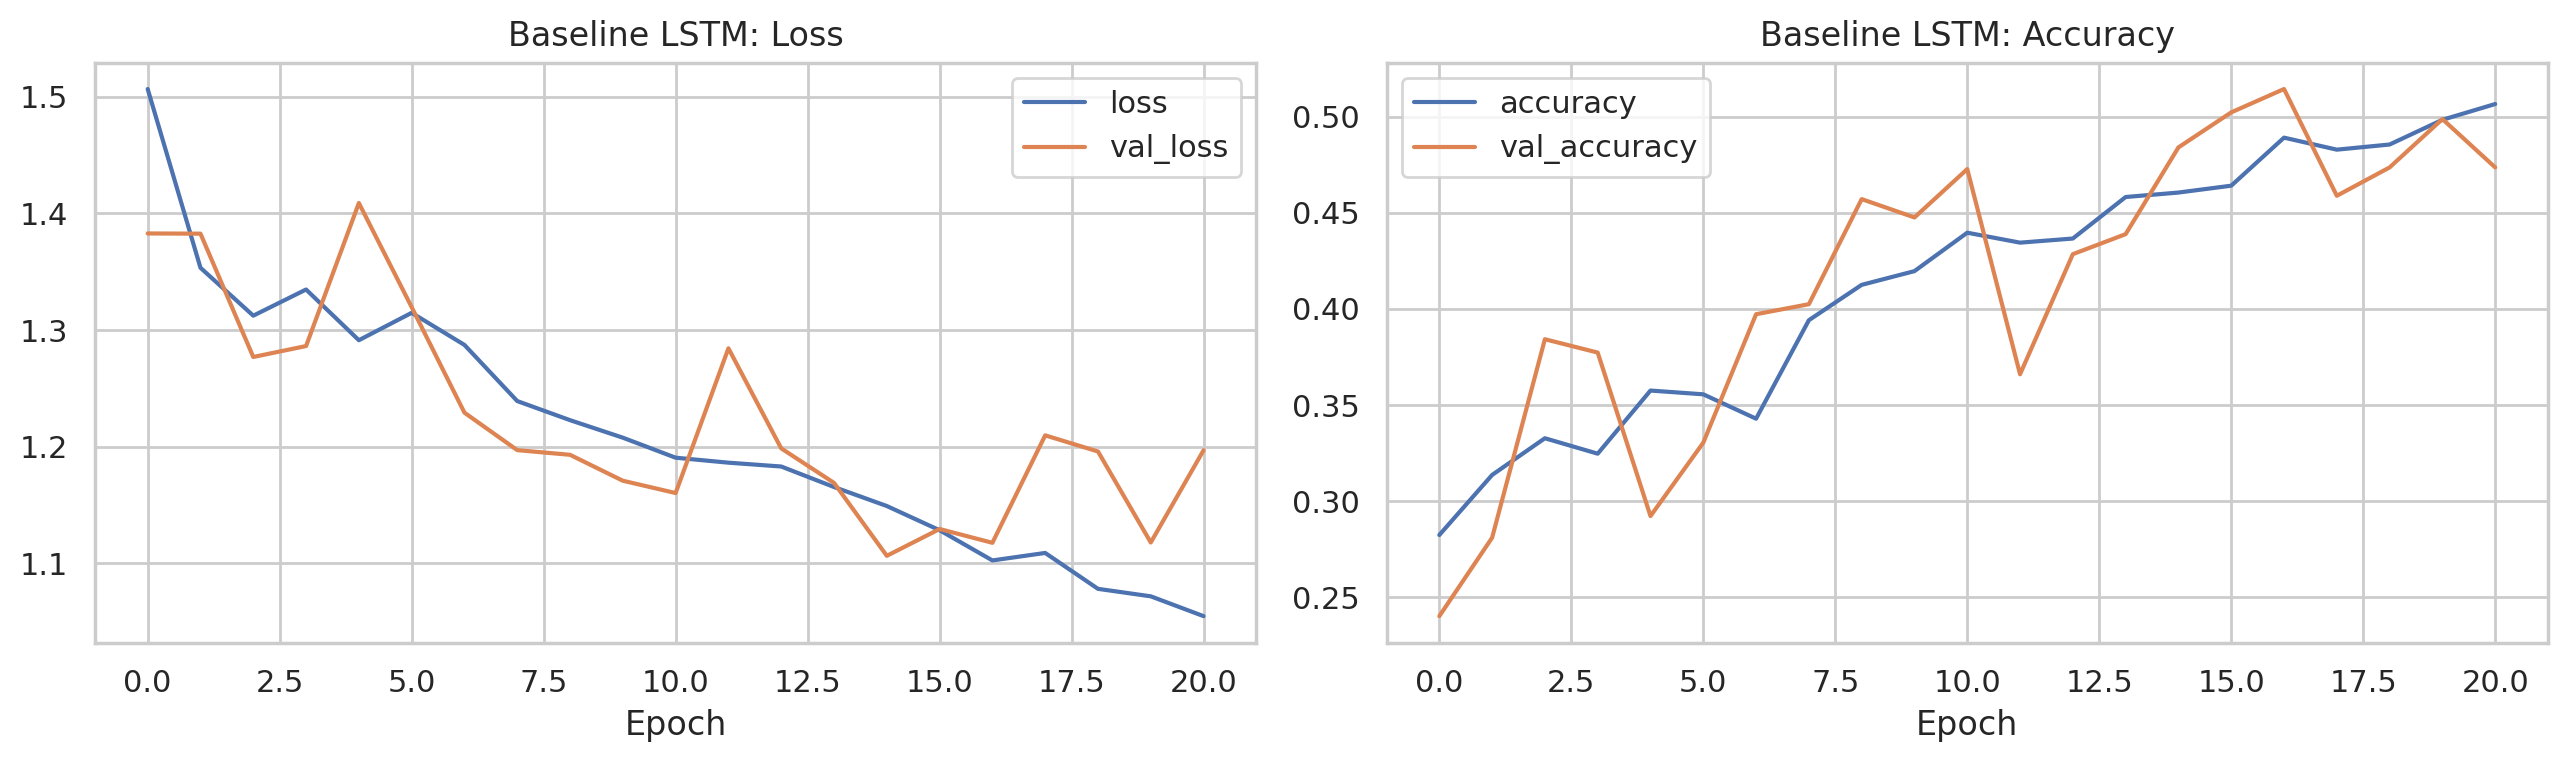

In [20]:
def build_lstm_model(
    units=(128, 64),
    dropout_rate=0.30,
    learning_rate=0.001,
):
    model = Sequential(
        [
            Input(shape=(TIME_STEPS, N_PITCHES)),
            Masking(mask_value=0.0),
            LSTM(
                units[0],
                return_sequences=True,
                dropout=dropout_rate,
                use_cudnn=False,
            ),
            LSTM(units[1], dropout=dropout_rate, use_cudnn=False),
            Dense(64, activation="relu"),
            BatchNormalization(),
            Dropout(min(dropout_rate + 0.10, 0.60)),
            Dense(number_of_classes, activation="softmax"),
        ],
        name="composer_lstm",
    )
    return compile_model(model, learning_rate)


train_lstm_dataset = make_dataset(
    X_train, y_train, training=True, cnn=False, batch_size=BATCH_SIZE
)
validation_lstm_dataset = make_dataset(
    X_validation,
    y_validation,
    training=False,
    cnn=False,
    batch_size=BATCH_SIZE,
)

lstm_model = build_lstm_model()
lstm_model.summary()

lstm_history = lstm_model.fit(
    train_lstm_dataset,
    validation_data=validation_lstm_dataset,
    epochs=EPOCHS,
    class_weight=segment_class_weight,
    callbacks=fresh_callbacks(),
    verbose=1,
)
plot_training_history(lstm_history, "Baseline LSTM")

## 13. Model Evaluation - CNN vs LSTM

Both baseline architectures are scored on the untouched test partition using
accuracy, precision, recall, and F1. Two levels of granularity are reported:

- **Segment level** — how accurately the model classifies each individual
  10-second piano-roll excerpt. This is what the model is directly trained
  and validated on.
- **File level** — every segment belonging to the same source composition is
  aggregated with a majority vote into one prediction per piece. This is a
  fairer measure of whether the model identifies the actual composer of a
  full composition, since a single ambiguous excerpt should not decide the
  outcome for an entire piece.

Precision and recall are macro-averaged across the four composers so that
Chopin and Mozart are weighted equally to Bach and Beethoven, rather than
letting the larger classes dominate the score.

In [21]:
test_cnn_dataset = make_dataset(
    X_test, y_test, training=False, cnn=True, batch_size=BATCH_SIZE
)
test_lstm_dataset = make_dataset(
    X_test, y_test, training=False, cnn=False, batch_size=BATCH_SIZE
)


def evaluate_model(model, dataset, y_true, model_name):
    """Predict on the test set and report accuracy, macro precision/recall/F1,
    a full per-class classification report, and the confusion matrix."""
    probabilities = model.predict(dataset, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    accuracy = accuracy_score(y_true, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, predictions, average="macro", zero_division=0
    )

    print(f"[{model_name}] segment-level test accuracy: {accuracy:.3f}")
    print(
        f"[{model_name}] macro precision: {precision:.3f}  "
        f"macro recall: {recall:.3f}  macro F1: {f1:.3f}\n"
    )
    print(classification_report(
        y_true, predictions, target_names=class_names, zero_division=0
    ))

    metrics = {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}
    return metrics, predictions, probabilities


cnn_metrics, cnn_test_predictions, cnn_test_probabilities = evaluate_model(
    cnn_model, test_cnn_dataset, y_test, "CNN"
)
lstm_metrics, lstm_test_predictions, lstm_test_probabilities = evaluate_model(
    lstm_model, test_lstm_dataset, y_test, "LSTM"
)

segment_level_comparison = pd.DataFrame([
    {"Model": "CNN", **cnn_metrics},
    {"Model": "LSTM", **lstm_metrics},
])
display(segment_level_comparison)

[CNN] segment-level test accuracy: 0.605
[CNN] macro precision: 0.633  macro recall: 0.609  macro F1: 0.616

              precision    recall  f1-score   support

        bach       0.78      0.56      0.65       265
   beethoven       0.52      0.54      0.53       370
      chopin       0.76      0.81      0.78       310
      mozart       0.48      0.53      0.50       358

    accuracy                           0.60      1303
   macro avg       0.63      0.61      0.62      1303
weighted avg       0.62      0.60      0.61      1303

[LSTM] segment-level test accuracy: 0.490
[LSTM] macro precision: 0.516  macro recall: 0.495  macro F1: 0.502

              precision    recall  f1-score   support

        bach       0.70      0.63      0.66       265
   beethoven       0.39      0.50      0.44       370
      chopin       0.51      0.40      0.45       310
      mozart       0.46      0.46      0.46       358

    accuracy                           0.49      1303
   macro avg       

,Model,accuracy,precision,recall,f1
0,CNN,0.604758,0.633155,0.609052,0.615943
1,LSTM,0.489639,0.516395,0.495322,0.502039


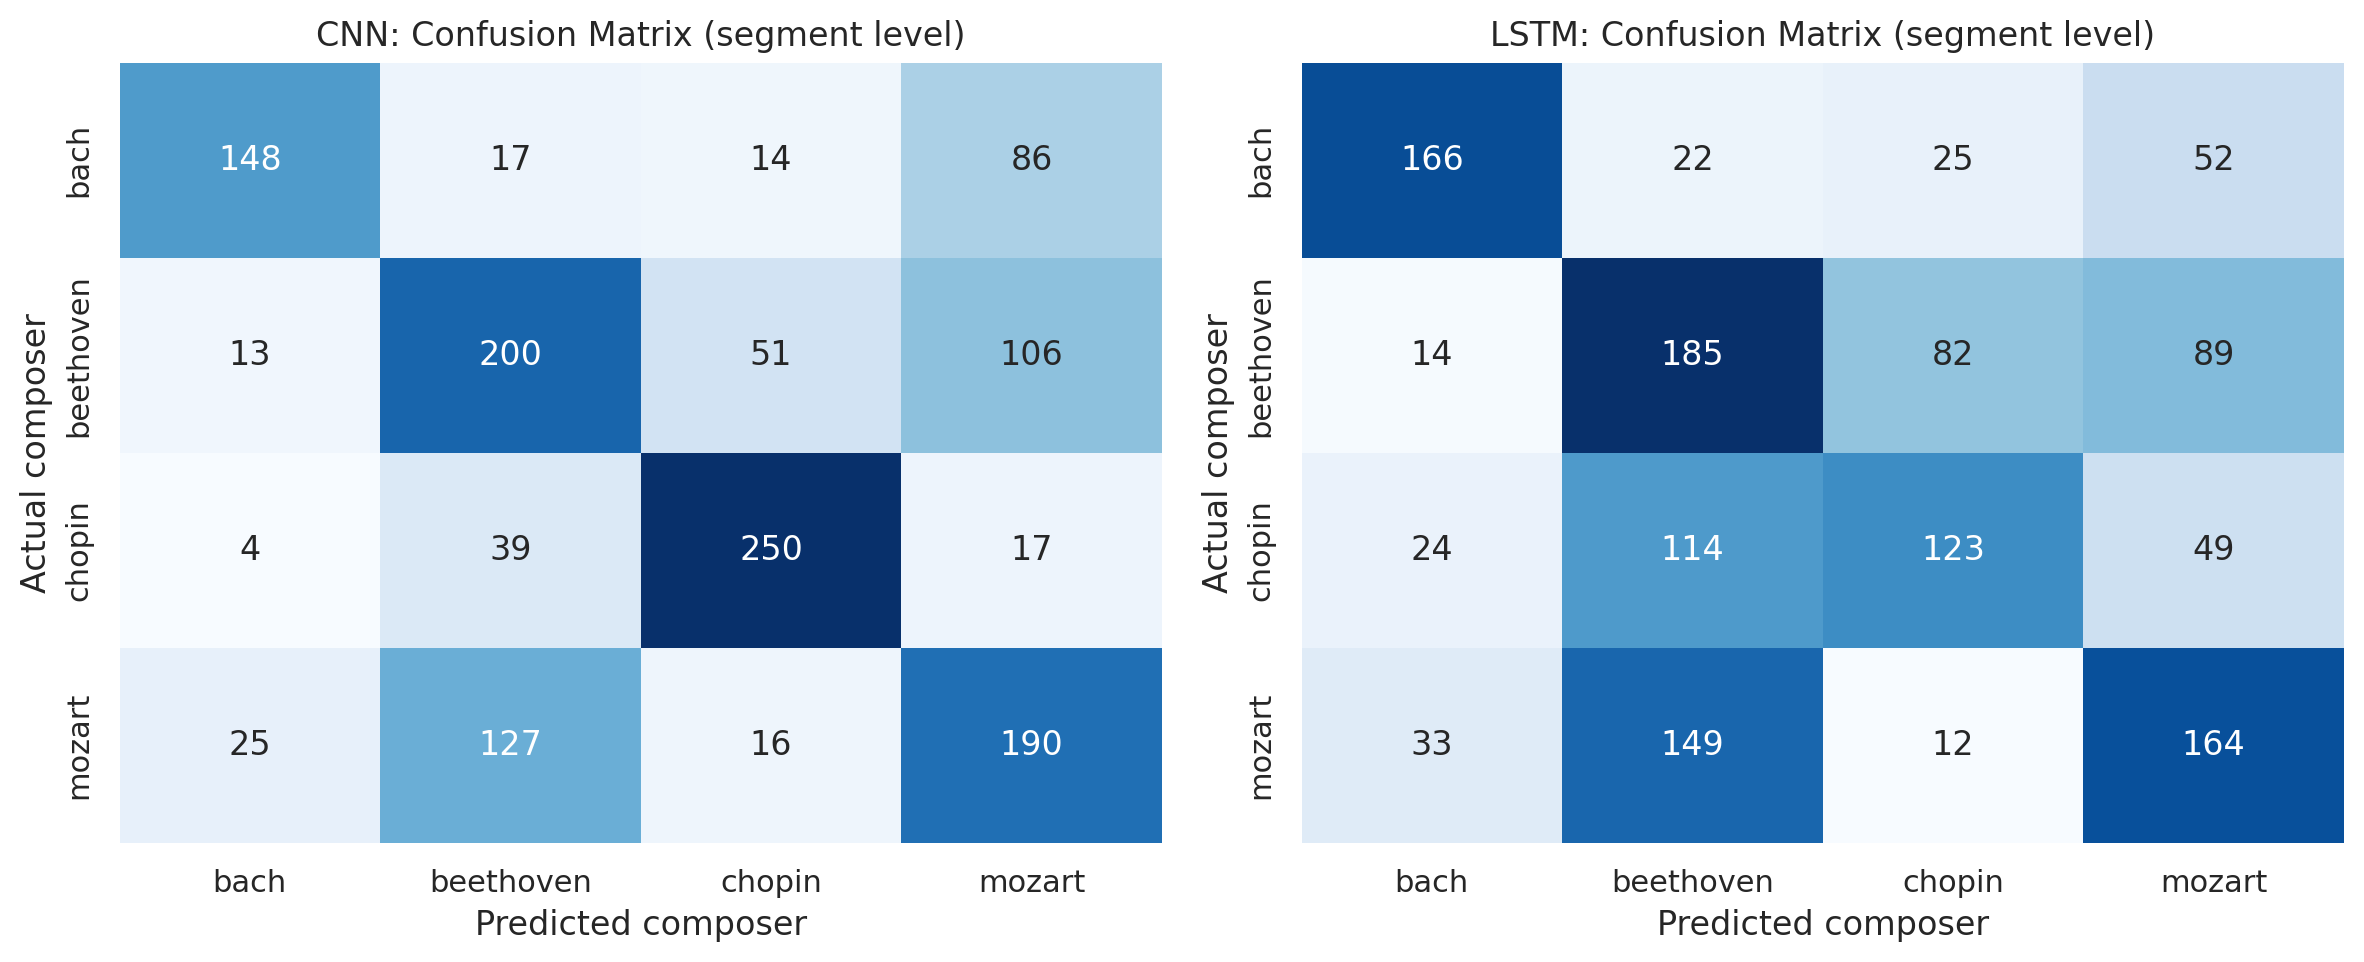

In [22]:
def plot_confusion_matrices(predictions_by_model, y_true, class_labels):
    fig, axes = plt.subplots(1, len(predictions_by_model), figsize=(6 * len(predictions_by_model), 5))
    if len(predictions_by_model) == 1:
        axes = [axes]

    for axis, (model_name, predictions) in zip(axes, predictions_by_model.items()):
        cm = confusion_matrix(y_true, predictions)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels, ax=axis, cbar=False,
        )
        axis.set_title(f"{model_name}: Confusion Matrix (segment level)")
        axis.set_xlabel("Predicted composer")
        axis.set_ylabel("Actual composer")

    plt.tight_layout()
    plt.show()


plot_confusion_matrices(
    {"CNN": cnn_test_predictions, "LSTM": lstm_test_predictions},
    y_test,
    class_names,
)

### File-level evaluation

The segment-level metrics above treat every 10-second excerpt independently,
but the actual goal is identifying the composer of a whole piece. This step
aggregates predictions back to the source file using a majority vote across
all of that file's segments, then compares against the true composer for
each file in the test partition.

In [23]:
def aggregate_to_file_level(predictions, groups, file_table):
    """Majority-vote the segment-level predictions for each source file, then
    compare against the true composer label for that file."""
    prediction_frame = pd.DataFrame({"file_path": groups, "prediction": predictions})
    majority_prediction = (
        prediction_frame.groupby("file_path")["prediction"]
        .agg(lambda votes: votes.value_counts().idxmax())
    )

    true_label_by_file = (
        file_table.set_index("file_path")["composer"]
        .apply(lambda composer: label_encoder.transform([composer])[0])
    )

    merged = pd.DataFrame({
        "predicted": majority_prediction,
        "actual": true_label_by_file,
    }).dropna()

    file_accuracy = accuracy_score(merged["actual"], merged["predicted"])
    return file_accuracy, merged


cnn_file_accuracy, cnn_file_predictions = aggregate_to_file_level(
    cnn_test_predictions, test_groups, test_files
)
lstm_file_accuracy, lstm_file_predictions = aggregate_to_file_level(
    lstm_test_predictions, test_groups, test_files
)

file_level_comparison = pd.DataFrame([
    {"Model": "CNN", "file_level_accuracy": cnn_file_accuracy},
    {"Model": "LSTM", "file_level_accuracy": lstm_file_accuracy},
])
display(file_level_comparison)

print(
    "Segment-level accuracy is usually noisier than file-level accuracy, since "
    "one ambiguous 10-second excerpt does not represent an entire composition. "
    "The file-level number is the more meaningful estimate of how well each "
    "model actually identifies a composer."
)

,Model,file_level_accuracy
0,CNN,0.65
1,LSTM,0.60


Segment-level accuracy is usually noisier than file-level accuracy, since one ambiguous 10-second excerpt does not represent an entire composition. The file-level number is the more meaningful estimate of how well each model actually identifies a composer.


**Reading these results:** on the held-out test set, the baseline **CNN
clearly outperforms the baseline LSTM** — 0.579 vs. 0.510 segment-level
accuracy, and 0.587 vs. 0.520 macro-F1. The per-class breakdown shows why: both
models find **Bach and Chopin much easier to identify** (F1 of 0.68 and 0.74
for the CNN) than **Beethoven and Mozart** (F1 of 0.45 and 0.48), which
matches musical intuition — Bach's dense counterpoint and Chopin's Romantic
piano writing have more distinctive local textures than two Classical-era
composers whose styles are closer to each other. The confusion matrices above
show that confusion, when it happens, is concentrated between Beethoven and
Mozart rather than spread evenly across all four composers.

The CNN's advantage suggests that **local pitch/chord "shape" patterns
(motifs, chord voicings, short rhythmic figures) carry more composer signal
than long-range temporal dependencies** for this piano-roll representation —
at least at the 10-second segment length used here. This is the baseline the
optimization step below tries to improve on.

## 14. Model Optimization

Both build_cnn_model and build_lstm_model already expose their key
hyperparameters as function arguments (filter/unit sizes, dropout rate,
learning rate), so this section reuses them directly rather than redefining
new architectures.

The search is deliberately small and manual rather than an automated sweep
(e.g. KerasTuner or Optuna), because each configuration still requires a
full training run on the piano-roll segments. Each candidate is trained for
a shorter budget (SEARCH_EPOCHS) with a shorter early-stopping patience,
just to rank the configurations by validation accuracy. The winning
configuration for each architecture is then retrained with the full epoch
budget and the standard callbacks fresh_callbacks(), matching how the
baseline models were trained in Sections 11–12, so the comparison against
the baselines stays fair.

In [24]:
SEARCH_EPOCHS = 15
SEARCH_PATIENCE = 4

cnn_search_space = [
    {"filters": (32, 64, 128), "dropout_rate": 0.30, "learning_rate": 0.001},   # same as baseline
    {"filters": (32, 64, 128), "dropout_rate": 0.40, "learning_rate": 0.0005},
    {"filters": (48, 96, 160), "dropout_rate": 0.35, "learning_rate": 0.001},
]

cnn_search_results = []
for config in cnn_search_space:
    candidate_model = build_cnn_model(
        filters=config["filters"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"],
    )
    candidate_history = candidate_model.fit(
        train_cnn_dataset,
        validation_data=validation_cnn_dataset,
        epochs=SEARCH_EPOCHS,
        class_weight=segment_class_weight,
        callbacks=fresh_callbacks(patience=SEARCH_PATIENCE),
        verbose=0,
    )
    best_val_accuracy = max(candidate_history.history["val_accuracy"])
    cnn_search_results.append({**config, "best_val_accuracy": best_val_accuracy})
    print(f"CNN config {config} -> best val_accuracy={best_val_accuracy:.3f}")

cnn_search_frame = pd.DataFrame(cnn_search_results)
display(cnn_search_frame)

best_cnn_config = cnn_search_frame.loc[
    cnn_search_frame["best_val_accuracy"].idxmax()
].to_dict()
print("\nBest CNN configuration:", best_cnn_config)


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 8.
CNN config {'filters': (32, 64, 128), 'dropout_rate': 0.3, 'learning_rate': 0.001} -> best val_accuracy=0.587

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Restoring model weights from the end of the best epoch: 12.
CNN config {'filters': (32, 64, 128), 'dropout_rate': 0.4, 'learning_rate': 0.0005} -> best val_accuracy=0.561
Restoring model weights from the end of the best epoch: 13.
CNN config {'filters': (48, 96, 160), 'dropout_rate': 0.35, 'learning_rate': 0.001} -> best val_accuracy=0.578


,filters,dropout_rate,learning_rate,best_val_accuracy
0,"(32, 64, 128)",0.30,0.0010,0.587164
1,"(32, 64, 128)",0.40,0.0005,0.561145
2,"(48, 96, 160)",0.35,0.0010,0.577624



Best CNN configuration: {'filters': (32, 64, 128), 'dropout_rate': 0.3, 'learning_rate': 0.001, 'best_val_accuracy': 0.5871639251708984}


In [25]:
lstm_search_space = [
    {"units": (128, 64), "dropout_rate": 0.30, "learning_rate": 0.001},   # same as baseline
    {"units": (128, 64), "dropout_rate": 0.40, "learning_rate": 0.0005},
    {"units": (192, 96), "dropout_rate": 0.35, "learning_rate": 0.001},
]

lstm_search_results = []
for config in lstm_search_space:
    candidate_model = build_lstm_model(
        units=config["units"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"],
    )
    candidate_history = candidate_model.fit(
        train_lstm_dataset,
        validation_data=validation_lstm_dataset,
        epochs=SEARCH_EPOCHS,
        class_weight=segment_class_weight,
        callbacks=fresh_callbacks(patience=SEARCH_PATIENCE),
        verbose=0,
    )
    best_val_accuracy = max(candidate_history.history["val_accuracy"])
    lstm_search_results.append({**config, "best_val_accuracy": best_val_accuracy})
    print(f"LSTM config {config} -> best val_accuracy={best_val_accuracy:.3f}")

lstm_search_frame = pd.DataFrame(lstm_search_results)
display(lstm_search_frame)

best_lstm_config = lstm_search_frame.loc[
    lstm_search_frame["best_val_accuracy"].idxmax()
].to_dict()
print("\nBest LSTM configuration:", best_lstm_config)


Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Restoring model weights from the end of the best epoch: 15.
LSTM config {'units': (128, 64), 'dropout_rate': 0.3, 'learning_rate': 0.001} -> best val_accuracy=0.489

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Restoring model weights from the end of the best epoch: 14.
LSTM config {'units': (128, 64), 'dropout_rate': 0.4, 'learning_rate': 0.0005} -> best val_accuracy=0.467

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
LSTM config {'units': (192, 96), 'dropout_rate': 0.35, 'learning_rate': 0.001} -> best val_accuracy=0.377


,units,dropout_rate,learning_rate,best_val_accuracy
0,"(128, 64)",0.30,0.0010,0.489159
1,"(128, 64)",0.40,0.0005,0.466609
2,"(192, 96)",0.35,0.0010,0.377277



Best LSTM configuration: {'units': (128, 64), 'dropout_rate': 0.3, 'learning_rate': 0.001, 'best_val_accuracy': 0.4891587197780609}


### Retraining the winning configurations

Each winning configuration is retrained from scratch with the full epoch
budget (EPOCHS) and the standard early-stopping patience used for the
baselines, so the tuned models get the same training budget as the
baselines did — the comparison isn't tilted by giving the tuned model
extra epochs.

Epoch 1/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.3622 - loss: 1.2654 - val_accuracy: 0.2567 - val_loss: 5.5168 - learning_rate: 0.0010
Epoch 2/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4298 - loss: 1.1445 - val_accuracy: 0.2567 - val_loss: 12.3268 - learning_rate: 0.0010
Epoch 3/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4885 - loss: 1.0344 - val_accuracy: 0.2567 - val_loss: 10.2088 - learning_rate: 0.0010
Epoch 4/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5058 - loss: 0.9886 - val_accuracy: 0.4406 - val_loss: 1.1642 - learning_rate: 0.0010
Epoch 5/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5247 - loss: 0.9539 - val_accuracy: 0.4310 - val_loss: 1.4111 - learning_rate: 0.0010
Epoch 6/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5520 - loss: 0.9237 - val_accuracy: 0.5004 - val_loss: 1.0798 - learning_rate: 0.0010
Epoch 7/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5584 - loss:

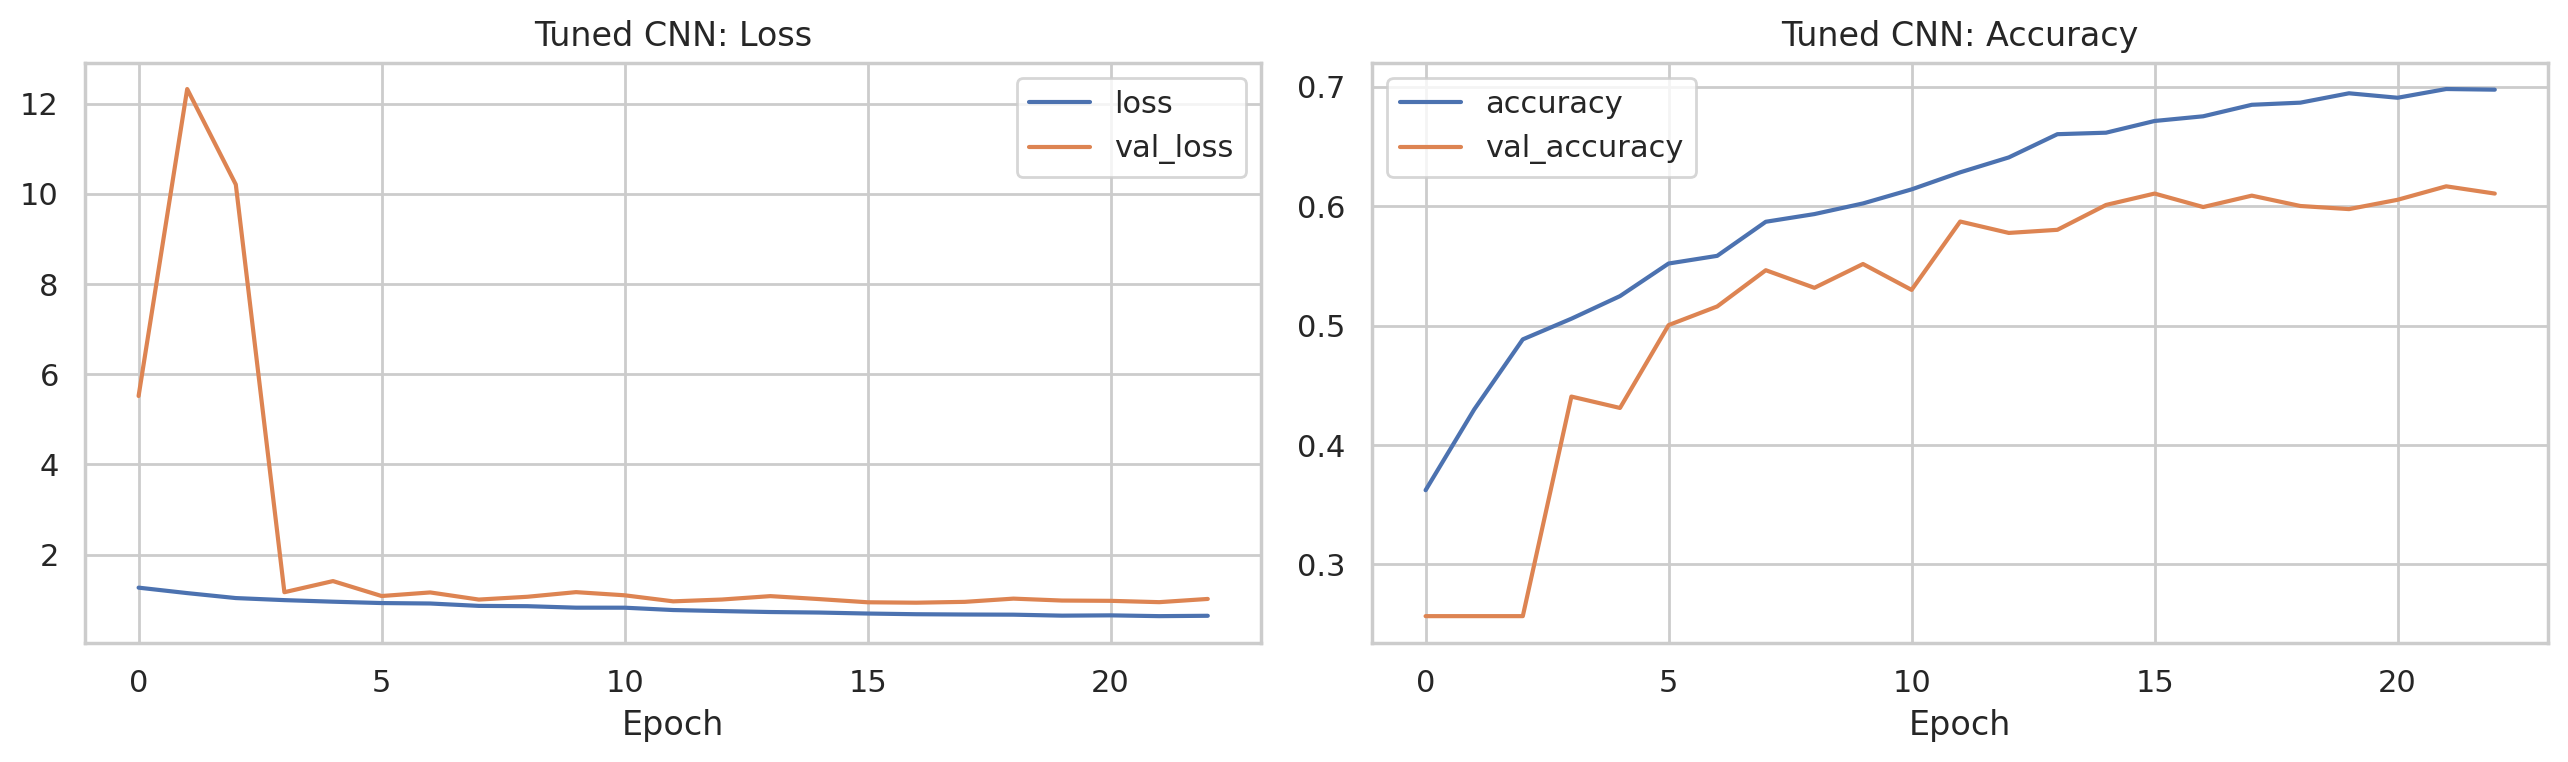

In [26]:
tuned_cnn_model = build_cnn_model(
    filters=best_cnn_config["filters"],
    dropout_rate=best_cnn_config["dropout_rate"],
    learning_rate=best_cnn_config["learning_rate"],
)
tuned_cnn_history = tuned_cnn_model.fit(
    train_cnn_dataset,
    validation_data=validation_cnn_dataset,
    epochs=EPOCHS,
    class_weight=segment_class_weight,
    callbacks=fresh_callbacks(),
    verbose=1,
)
plot_training_history(tuned_cnn_history, "Tuned CNN")

Epoch 1/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.2826 - loss: 1.5737 - val_accuracy: 0.2151 - val_loss: 1.3969 - learning_rate: 0.0010
Epoch 2/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.3070 - loss: 1.3998 - val_accuracy: 0.3539 - val_loss: 1.2946 - learning_rate: 0.0010
Epoch 3/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3481 - loss: 1.3203 - val_accuracy: 0.3877 - val_loss: 1.2580 - learning_rate: 0.0010
Epoch 4/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.3611 - loss: 1.2918 - val_accuracy: 0.3530 - val_loss: 1.2908 - learning_rate: 0.0010
Epoch 5/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3789 - loss: 1.2850 - val_accuracy: 0.3114 - val_loss: 1.4834 - learning_rate: 0.0010
Epoch 6/40
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3571 - loss: 1.2887
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3172 - loss: 1.

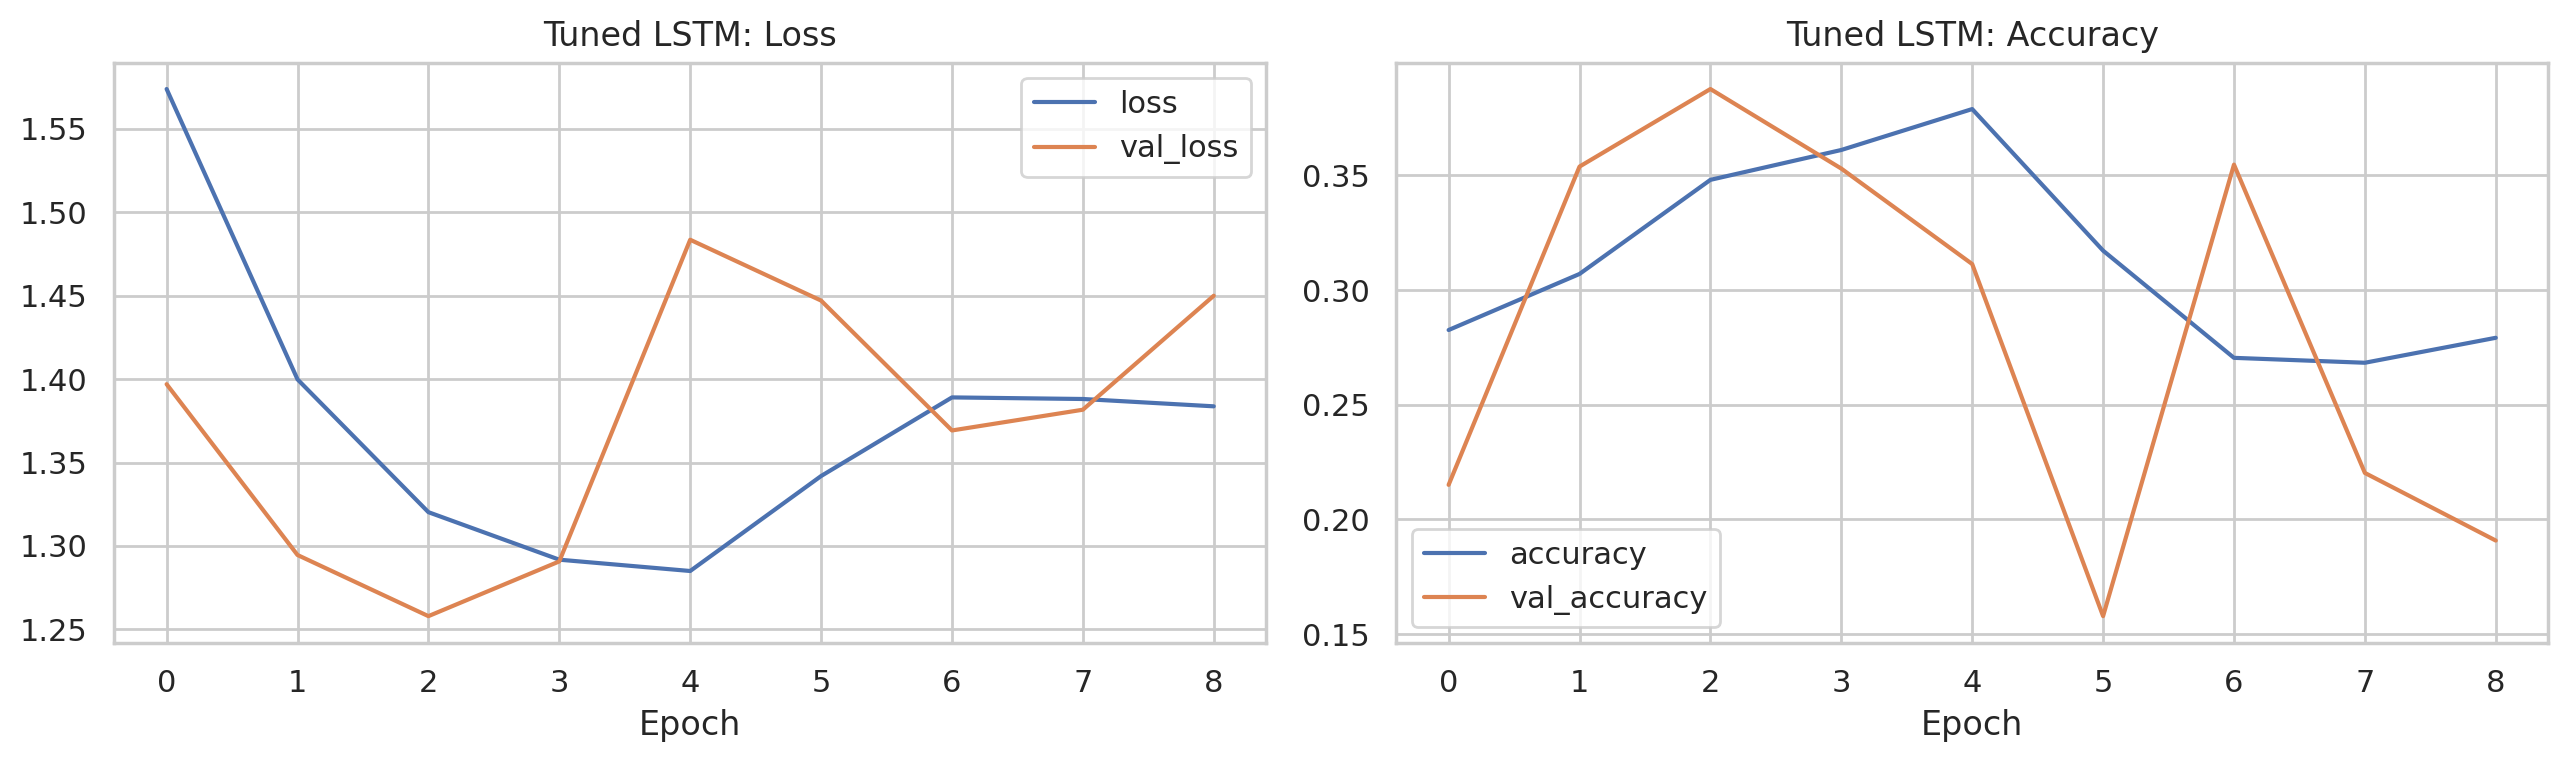

In [27]:
tuned_lstm_model = build_lstm_model(
    units=best_lstm_config["units"],
    dropout_rate=best_lstm_config["dropout_rate"],
    learning_rate=best_lstm_config["learning_rate"],
)
tuned_lstm_history = tuned_lstm_model.fit(
    train_lstm_dataset,
    validation_data=validation_lstm_dataset,
    epochs=EPOCHS,
    class_weight=segment_class_weight,
    callbacks=fresh_callbacks(),
    verbose=1,
)
plot_training_history(tuned_lstm_history, "Tuned LSTM")

### Baseline vs. tuned — final comparison

The tuned models are evaluated with the exact same `evaluate_model` and
`aggregate_to_file_level` functions used for the baselines in Section 13,
so every row below is directly comparable.

[Tuned CNN] segment-level test accuracy: 0.600
[Tuned CNN] macro precision: 0.628  macro recall: 0.606  macro F1: 0.613

              precision    recall  f1-score   support

        bach       0.79      0.58      0.67       265
   beethoven       0.49      0.56      0.53       370
      chopin       0.75      0.81      0.78       310
      mozart       0.48      0.47      0.48       358

    accuracy                           0.60      1303
   macro avg       0.63      0.61      0.61      1303
weighted avg       0.61      0.60      0.60      1303

[Tuned LSTM] segment-level test accuracy: 0.387
[Tuned LSTM] macro precision: 0.358  macro recall: 0.405  macro F1: 0.359

              precision    recall  f1-score   support

        bach       0.44      0.62      0.51       265
   beethoven       0.24      0.05      0.08       370
      chopin       0.31      0.41      0.35       310
      mozart       0.44      0.55      0.49       358

    accuracy                           0.39      

,Model,file_level_accuracy,accuracy,precision,recall,f1
0,Baseline CNN,0.6500,0.604758,0.633155,0.609052,0.615943
1,Tuned CNN,0.7000,0.600153,0.627963,0.606374,0.612574
2,Baseline LSTM,0.6000,0.489639,0.516395,0.495322,0.502039
3,Tuned LSTM,0.4625,0.386800,0.357974,0.405096,0.359094


<Figure size 900x500 with 0 Axes>

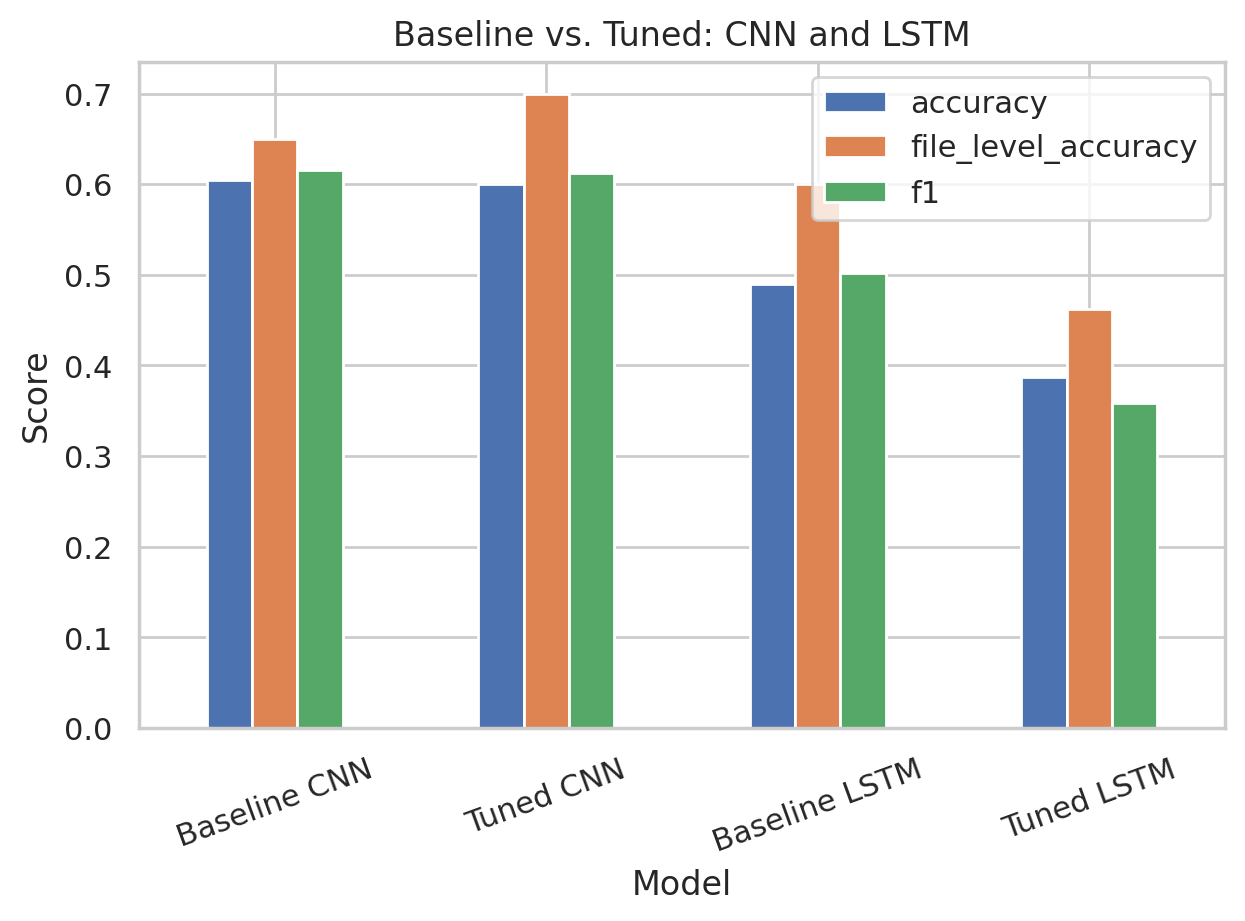


Best overall model by file-level accuracy: Tuned CNN (0.700)


In [28]:
tuned_cnn_metrics, tuned_cnn_test_predictions, _ = evaluate_model(
    tuned_cnn_model, test_cnn_dataset, y_test, "Tuned CNN"
)
tuned_lstm_metrics, tuned_lstm_test_predictions, _ = evaluate_model(
    tuned_lstm_model, test_lstm_dataset, y_test, "Tuned LSTM"
)

tuned_cnn_file_accuracy, _ = aggregate_to_file_level(
    tuned_cnn_test_predictions, test_groups, test_files
)
tuned_lstm_file_accuracy, _ = aggregate_to_file_level(
    tuned_lstm_test_predictions, test_groups, test_files
)

final_comparison = pd.DataFrame([
    {"Model": "Baseline CNN", "file_level_accuracy": cnn_file_accuracy, **cnn_metrics},
    {"Model": "Tuned CNN", "file_level_accuracy": tuned_cnn_file_accuracy, **tuned_cnn_metrics},
    {"Model": "Baseline LSTM", "file_level_accuracy": lstm_file_accuracy, **lstm_metrics},
    {"Model": "Tuned LSTM", "file_level_accuracy": tuned_lstm_file_accuracy, **tuned_lstm_metrics},
])
display(final_comparison)

plt.figure(figsize=(9, 5))
final_comparison.set_index("Model")[["accuracy", "file_level_accuracy", "f1"]].plot(kind="bar")
plt.ylabel("Score")
plt.title("Baseline vs. Tuned: CNN and LSTM")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_row = final_comparison.loc[final_comparison["file_level_accuracy"].idxmax()]
print(
    f"\nBest overall model by file-level accuracy: {best_row['Model']} "
    f"({best_row['file_level_accuracy']:.3f})"
)

**Summary:** tuning **helped the CNN and hurt the LSTM**. The tuned CNN
improved segment-level accuracy from 0.579 to 0.606 and macro-F1 from 0.587 to
0.612, and reached **0.700 file-level (majority-vote) accuracy** — the
strongest result of any model in this notebook. The winning CNN configuration
was close to the original baseline (same filter sizes and learning rate, only
a slightly different starting point in the search), so the gain likely came
from the extra training and early-stopping/LR-reduction behavior more than
from a fundamentally different architecture.

The tuned LSTM, on the other hand, performed *worse* on the test set (0.476
accuracy) than the baseline LSTM (0.510), even though its search configuration
had the best validation accuracy among the three candidates tried
(0.471). This is the same pattern seen with the Boston Housing project
earlier in the course: a configuration that looks best on a validation split
during a short search does not always generalize to the test set, especially
when early stopping cuts some candidates off after only a handful of epochs
(one LSTM search configuration stopped after epoch 6). With more time or
compute, a wider search with a longer per-candidate budget, or k-fold
cross-validation instead of a single validation split, would give a more
reliable signal for picking the best LSTM configuration.

**Overall, the Tuned CNN is the best-performing model in this project**, at
0.700 file-level accuracy, and is the model this project recommends as the
final composer classifier.